# Medical Symptom Triage Conversational

Independent notebook for a new NLP project based on the Hugging Face dataset:
`"sweatSmile/medical-symptom-triage-conversational"`.

This notebook is intentionally separate from previous projects.

## Planned Pipeline (aligned with project requirements)

1. **Code settings / imports** - libraries for NLP, ML, visualization, class balancing.
2. **Gathering the data** - load medical triage dataset (`messages`, `specialty`, `urgency`, `confidence`, `id`).
3. **Preprocessing** - clean text, remove empty rows, normalize whitespace and casing.
4. **Preliminary exploration** - inspect class distributions; merge rare `specialty` classes (<100) into `Other`.
5. **Feature engineering** - POS/NER extraction, token filtering (`NOUN`, `VERB`), NER-based text features + TF-IDF.
6. **Exploring numerical features** - entity count features, histograms, basic correlations.
7. **Train/validation split policy** - use provided Hugging Face splits directly (`train` + `validation`).
8. **Feasibility / imbalance** - evaluate class imbalance and apply `SMOTE` (or fallback oversampling).
9. **Feature selection** - optional top-N TF-IDF feature filtering for ablation checks.
10. **Machine learning loop** - train `SVM` and `Logistic Regression`; evaluate `Accuracy`, `Balanced Accuracy`, `F1`, `MCC`, `Cohen Kappa`.

In [1]:
# 1) Optional install (run only if needed)
# %pip install -q datasets huggingface_hub pandas

In [2]:
# 2) Load dataset from Hugging Face
from datasets import load_dataset

DATASET_ID = "sweatSmile/medical-symptom-triage-conversational"

try:
    ds = load_dataset(DATASET_ID)
    print("Dataset loaded successfully:", DATASET_ID)
except Exception as e:
    print("Dataset could not be loaded directly.")
    print("If it is gated/private, run in terminal: huggingface-cli login")
    raise

print(ds)
print("Splits:", list(ds.keys()))

ModuleNotFoundError: No module named 'datasets'

In [ ]:
# 3) Quick schema and sample preview
import pandas as pd

# Choose first available split (usually train)
split_name = "train" if "train" in ds else list(ds.keys())[0]
print("Using split:", split_name)

print("\nFeatures:")
print(ds[split_name].features)

print("\nFirst record:")
print(ds[split_name][0])

# Small DataFrame preview
preview_df = ds[split_name].select(range(min(5, len(ds[split_name])))).to_pandas()
print("\nPreview shape:", preview_df.shape)
display(preview_df)

Using split: train

Features:
{'messages': Value('string'), 'specialty': Value('string'), 'urgency': Value('string'), 'confidence': Value('float32'), 'id': Value('int64')}

First record:
{'messages': '[{\'role\': \'system\', \'content\': \'You are a medical triage specialist. Analyze patient symptoms and recommend appropriate specialist referrals with urgency levels and clinical reasoning.\'}, {\'role\': \'user\', \'content\': "Patient Information:\\n- Symptoms: I\'ve been having crushing chest pain in the center of my chest for the last hour. It feels like an elephant is sitting on my chest. The pain is radiating down my left arm and up into my jaw. I\'m also very sweaty, nauseous, and short of breath. I took some antacids thinking it was heartburn but it didn\'t help at all. I\'ve never felt anything like this before.\\n- Demographics: 58-year-old male, overweight, smoker\\n- Duration: Acute onset 1 hour ago\\n- Severity: Severe, debilitating pain 8/10, preventing any activity\\n\\nP

,messages,specialty,urgency,confidence,id
0,"[{'role': 'system', 'content': 'You are a medi...",Cardiology,Emergency,0.95,1
1,"[{'role': 'system', 'content': 'You are a medi...",Cardiology,Emergency,0.95,2
2,"[{'role': 'system', 'content': 'You are a medi...",Cardiology,Emergency,0.95,3
3,"[{'role': 'system', 'content': 'You are a medi...",Cardiology,Emergency,0.95,4
4,"[{'role': 'system', 'content': 'You are a medi...",Cardiology,Emergency,0.95,5


In [ ]:
# 4) Optional: export split to CSV for offline analysis
# Uncomment if you want local CSV files.

# for split in ds.keys():
#     out_path = f"medical_symptom_triage_{split}.csv"
#     ds[split].to_pandas().to_csv(out_path, index=False)
#     print("Saved:", out_path)

In [ ]:
# 5) Deep overview: split sizes + feature schema
from pprint import pprint

print("=== DATASET OVERVIEW ===")
print(ds)

for split in ds.keys():
    print(f"\n--- Split: {split} ---")
    print("Rows:", len(ds[split]))
    print("Features:")
    pprint(ds[split].features)


=== DATASET OVERVIEW ===
DatasetDict({
    train: Dataset({
        features: ['messages', 'specialty', 'urgency', 'confidence', 'id'],
        num_rows: 1112
    })
    validation: Dataset({
        features: ['messages', 'specialty', 'urgency', 'confidence', 'id'],
        num_rows: 278
    })
})

--- Split: train ---
Rows: 1112
Features:
{'confidence': Value('float32'),
 'id': Value('int64'),
 'messages': Value('string'),
 'specialty': Value('string'),
 'urgency': Value('string')}

--- Split: validation ---
Rows: 278
Features:
{'confidence': Value('float32'),
 'id': Value('int64'),
 'messages': Value('string'),
 'specialty': Value('string'),
 'urgency': Value('string')}


In [ ]:
# 6) Raw sample inspection (full records)
import json

split_name = "train" if "train" in ds else list(ds.keys())[0]
show_n = min(3, len(ds[split_name]))

print(f"Showing {show_n} full raw records from split={split_name}\n")
for i in range(show_n):
    print(f"===== RECORD {i} =====")
    print(json.dumps(ds[split_name][i], indent=2, ensure_ascii=False, default=str))
    print()


Showing 3 full raw records from split=train

===== RECORD 0 =====
{
  "messages": "[{'role': 'system', 'content': 'You are a medical triage specialist. Analyze patient symptoms and recommend appropriate specialist referrals with urgency levels and clinical reasoning.'}, {'role': 'user', 'content': \"Patient Information:\\n- Symptoms: I've been having crushing chest pain in the center of my chest for the last hour. It feels like an elephant is sitting on my chest. The pain is radiating down my left arm and up into my jaw. I'm also very sweaty, nauseous, and short of breath. I took some antacids thinking it was heartburn but it didn't help at all. I've never felt anything like this before.\\n- Demographics: 58-year-old male, overweight, smoker\\n- Duration: Acute onset 1 hour ago\\n- Severity: Severe, debilitating pain 8/10, preventing any activity\\n\\nPlease provide specialist referral recommendation.\"}, {'role': 'assistant', 'content': '**Specialist Referral Assessment**\\n\\n**Prima

In [ ]:
print(ds)
print(ds.keys())

DatasetDict({
    train: Dataset({
        features: ['messages', 'specialty', 'urgency', 'confidence', 'id'],
        num_rows: 1112
    })
    validation: Dataset({
        features: ['messages', 'specialty', 'urgency', 'confidence', 'id'],
        num_rows: 278
    })
})
dict_keys(['train', 'validation'])


In [ ]:
# 7) Column diagnostics: nulls, non-nulls, unique counts, sample values
import pandas as pd

split_name = "train" if "train" in ds else list(ds.keys())[0]
df = ds[split_name].to_pandas()

summary_rows = []
for col in df.columns:
    s = df[col]
    non_null = int(s.notna().sum())
    nulls = int(s.isna().sum())

    try:
        nunique = int(s.nunique(dropna=True))
    except Exception:
        nunique = -1

    sample_vals = s.dropna().head(3).astype(str).tolist()

    summary_rows.append(
        {
            "column": col,
            "dtype": str(s.dtype),
            "non_null": non_null,
            "nulls": nulls,
            "null_pct": round((nulls / len(df)) * 100, 2) if len(df) else 0.0,
            "nunique": nunique,
            "sample_values": sample_vals,
        }
    )

col_diag = pd.DataFrame(summary_rows).sort_values(["null_pct", "nunique"], ascending=[False, True])
print("Shape:", df.shape)
display(col_diag)


Shape: (1112, 5)


,column,dtype,non_null,nulls,null_pct,nunique,sample_values
2,urgency,object,1112,0,0.0,4,"[Emergency, Emergency, Emergency]"
3,confidence,float32,1112,0,0.0,5,"[0.95, 0.95, 0.95]"
1,specialty,object,1112,0,0.0,10,"[Cardiology, Cardiology, Cardiology]"
0,messages,object,1112,0,0.0,1112,"[[{'role': 'system', 'content': 'You are a med..."
4,id,int64,1112,0,0.0,1112,"[1, 2, 3]"


In [ ]:
# 8) Nested structure diagnostics (lists/dicts in cells)
from collections import Counter

split_name = "train" if "train" in ds else list(ds.keys())[0]
df = ds[split_name].to_pandas()

nested_report = []
max_scan = min(200, len(df))

for col in df.columns:
    type_counter = Counter(type(v).__name__ for v in df[col].head(max_scan))
    has_list = "list" in type_counter
    has_dict = "dict" in type_counter

    ex_list_len = None
    ex_dict_keys = None

    if has_list:
        for v in df[col].head(max_scan):
            if isinstance(v, list):
                ex_list_len = len(v)
                break

    if has_dict:
        for v in df[col].head(max_scan):
            if isinstance(v, dict):
                ex_dict_keys = list(v.keys())[:10]
                break

    nested_report.append(
        {
            "column": col,
            "type_distribution_sample": dict(type_counter),
            "contains_list": has_list,
            "contains_dict": has_dict,
            "example_list_len": ex_list_len,
            "example_dict_keys": ex_dict_keys,
        }
    )

nested_df = pd.DataFrame(nested_report)
display(nested_df)


,column,type_distribution_sample,contains_list,contains_dict,example_list_len,example_dict_keys
0,messages,{'str': 200},False,False,None,None
1,specialty,{'str': 200},False,False,None,None
2,urgency,{'str': 200},False,False,None,None
3,confidence,{'float': 200},False,False,None,None
4,id,{'int': 200},False,False,None,None


In [ ]:
# 9) Text-field profiling (length stats + quick examples)
import numpy as np

split_name = "train" if "train" in ds else list(ds.keys())[0]
df = ds[split_name].to_pandas()

text_cols = []
for col in df.columns:
    if df[col].dtype == "object":
        sample = df[col].dropna().head(30)
        if len(sample) > 0 and sample.map(lambda x: isinstance(x, str)).mean() > 0.7:
            text_cols.append(col)

print("Detected text-like columns:", text_cols)

rows = []
for col in text_cols:
    s = df[col].fillna("").astype(str)
    char_len = s.str.len()
    word_len = s.str.split().str.len()

    rows.append(
        {
            "column": col,
            "char_mean": round(float(char_len.mean()), 2),
            "char_p50": int(np.percentile(char_len, 50)),
            "char_p90": int(np.percentile(char_len, 90)),
            "char_max": int(char_len.max()),
            "word_mean": round(float(word_len.mean()), 2),
            "word_p50": int(np.percentile(word_len, 50)),
            "word_p90": int(np.percentile(word_len, 90)),
            "word_max": int(word_len.max()),
        }
    )

text_profile_df = pd.DataFrame(rows)
display(text_profile_df)

for col in text_cols[:3]:
    print(f"\n=== Example snippets for: {col} ===")
    snippets = df[col].dropna().astype(str).head(3).tolist()
    for i, sn in enumerate(snippets):
        print(f"[{i}]", sn[:300], "..." if len(sn) > 300 else "")


Detected text-like columns: ['messages', 'specialty', 'urgency']


,column,char_mean,char_p50,char_p90,char_max,word_mean,word_p50,word_p90,word_max
0,messages,1801.76,1794,1930,2134,223.04,222,243,270
1,specialty,11.88,11,18,18,1.22,1,2,2
2,urgency,7.15,7,9,11,1.00,1,1,1



=== Example snippets for: messages ===
[0] [{'role': 'system', 'content': 'You are a medical triage specialist. Analyze patient symptoms and recommend appropriate specialist referrals with urgency levels and clinical reasoning.'}, {'role': 'user', 'content': "Patient Information:\n- Symptoms: I've been having crushing chest pain in the cente ...
[1] [{'role': 'system', 'content': 'You are a medical triage specialist. Analyze patient symptoms and recommend appropriate specialist referrals with urgency levels and clinical reasoning.'}, {'role': 'user', 'content': "Patient Information:\n- Symptoms: I've been having crushing chest pain in the cente ...
[2] [{'role': 'system', 'content': 'You are a medical triage specialist. Analyze patient symptoms and recommend appropriate specialist referrals with urgency levels and clinical reasoning.'}, {'role': 'user', 'content': "Patient Information:\n- Symptoms: I'm having really bad chest pain that feels like  ...

=== Example snippets for: specia

In [ ]:
# 10) Potential label columns and class balance preview
split_name = "train" if "train" in ds else list(ds.keys())[0]
df = ds[split_name].to_pandas()

candidate_cols = []
for col in df.columns:
    s = df[col]
    # low-cardinality non-numeric or integer-like columns can be label candidates
    try:
        nunique = int(s.nunique(dropna=True))
    except Exception:
        nunique = 999999
    if 2 <= nunique <= 30:
        candidate_cols.append((col, nunique, str(s.dtype)))

print("Potential label-like columns (2..30 unique values):")
for col, nunique, dtype in candidate_cols:
    print(f"- {col} | unique={nunique} | dtype={dtype}")

for col, nunique, _ in candidate_cols[:5]:
    print(f"\n=== Distribution: {col} ===")
    vc = df[col].value_counts(dropna=False).head(20)
    display(vc)


Potential label-like columns (2..30 unique values):
- specialty | unique=10 | dtype=object
- urgency | unique=4 | dtype=object
- confidence | unique=5 | dtype=float32

=== Distribution: specialty ===


specialty
Cardiology            180
Emergency Medicine    150
Neurology             150
Dermatology           120
Orthopedics           120
Gastroenterology      100
Pulmonology           100
Mental Health         100
Urology                80
Endocrinology          12
Name: count, dtype: int64


=== Distribution: urgency ===


urgency
Routine        547
Urgent         381
Emergency       95
Observation     89
Name: count, dtype: int64


=== Distribution: confidence ===


confidence
0.95    505
0.85    416
0.89    105
0.92     72
0.98     14
Name: count, dtype: int64

In [ ]:
# 11) Prepare train/validation DataFrames and parse conversational messages
import ast
import re
import numpy as np
import pandas as pd

train_df = ds["train"].to_pandas().copy()
val_df = ds["validation"].to_pandas().copy()


def parse_messages_blob(blob):
    """Parse stringified list-of-dicts messages safely."""
    if isinstance(blob, list):
        parsed = blob
    elif isinstance(blob, str):
        try:
            parsed = ast.literal_eval(blob)
        except Exception:
            parsed = []
    else:
        parsed = []
    return parsed if isinstance(parsed, list) else []


def extract_role_text(messages_blob, role="user"):
    msgs = parse_messages_blob(messages_blob)
    texts = []
    for m in msgs:
        if isinstance(m, dict) and m.get("role") == role:
            txt = str(m.get("content", "")).strip()
            if txt:
                texts.append(txt)
    return "\n".join(texts)


for frame in (train_df, val_df):
    frame["user_text"] = frame["messages"].map(lambda x: extract_role_text(x, role="user"))
    frame["assistant_text"] = frame["messages"].map(lambda x: extract_role_text(x, role="assistant"))
    frame["system_text"] = frame["messages"].map(lambda x: extract_role_text(x, role="system"))

# For modeling triage decision, we use only patient/user content to avoid leakage from assistant answer.
train_df["full_text"] = train_df["user_text"].fillna("")
val_df["full_text"] = val_df["user_text"].fillna("")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Columns:", train_df.columns.tolist())

Train shape: (1112, 9)
Validation shape: (278, 9)
Columns: ['messages', 'specialty', 'urgency', 'confidence', 'id', 'user_text', 'assistant_text', 'system_text', 'full_text']


In [ ]:
# 12) Class distribution + merge rare specialty classes (<100) into 'Other'
MIN_SPECIALTY_COUNT = 100

print("=== ORIGINAL DISTRIBUTION: specialty (train) ===")
orig_specialty_counts = train_df["specialty"].value_counts()
display(orig_specialty_counts)

print("=== ORIGINAL DISTRIBUTION: urgency (train) ===")
display(train_df["urgency"].value_counts())

# Keep only stable classes from TRAIN, everything else -> Other
stable_specialties = set(orig_specialty_counts[orig_specialty_counts >= MIN_SPECIALTY_COUNT].index.tolist())
rare_specialties = sorted(set(orig_specialty_counts.index) - stable_specialties)

print(f"\nRare specialty classes (<{MIN_SPECIALTY_COUNT} rows):", rare_specialties)
print("Stable specialty classes used explicitly:", sorted(stable_specialties))


def map_specialty(x):
    # Critical guard: if validation has unseen specialty, map it to Other.
    return x if x in stable_specialties else "Other"


train_df["specialty_merged"] = train_df["specialty"].map(map_specialty)
val_df["specialty_merged"] = val_df["specialty"].map(map_specialty)

print("\n=== MERGED DISTRIBUTION: specialty_merged (train) ===")
display(train_df["specialty_merged"].value_counts())

print("\n=== MERGED DISTRIBUTION: specialty_merged (validation) ===")
display(val_df["specialty_merged"].value_counts())

print("\n=== Urgency distribution (validation) ===")
display(val_df["urgency"].value_counts())

=== ORIGINAL DISTRIBUTION: specialty (train) ===


specialty
Cardiology            180
Emergency Medicine    150
Neurology             150
Dermatology           120
Orthopedics           120
Gastroenterology      100
Pulmonology           100
Mental Health         100
Urology                80
Endocrinology          12
Name: count, dtype: int64

=== ORIGINAL DISTRIBUTION: urgency (train) ===


urgency
Routine        547
Urgent         381
Emergency       95
Observation     89
Name: count, dtype: int64


Rare specialty classes (<100 rows): ['Endocrinology', 'Urology']
Stable specialty classes used explicitly: ['Cardiology', 'Dermatology', 'Emergency Medicine', 'Gastroenterology', 'Mental Health', 'Neurology', 'Orthopedics', 'Pulmonology']

=== MERGED DISTRIBUTION: specialty_merged (train) ===


specialty_merged
Cardiology            180
Emergency Medicine    150
Neurology             150
Dermatology           120
Orthopedics           120
Gastroenterology      100
Pulmonology           100
Mental Health         100
Other                  92
Name: count, dtype: int64


=== MERGED DISTRIBUTION: specialty_merged (validation) ===


specialty_merged
Other    278
Name: count, dtype: int64


=== Urgency distribution (validation) ===


urgency
Routine        147
Urgent          91
Observation     23
Emergency       17
Name: count, dtype: int64

In [ ]:
# 13) Text cleaning + remove empty/duplicate records

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


for name, frame in [("train", train_df), ("validation", val_df)]:
    frame["clean_text"] = frame["full_text"].fillna("").map(clean_text)

    before = len(frame)
    frame.drop(frame[frame["clean_text"] == ""].index, inplace=True)

    # remove duplicates by text + targets
    frame.drop_duplicates(subset=["clean_text", "specialty_merged", "urgency"], inplace=True)
    frame.reset_index(drop=True, inplace=True)

    after = len(frame)
    print(f"{name}: before={before}, after_clean_dedup={after}, removed={before - after}")

print("\nTrain head:")
display(train_df[["clean_text", "specialty_merged", "urgency"]].head(3))

train: before=1112, after_clean_dedup=1107, removed=5
validation: before=278, after_clean_dedup=277, removed=1

Train head:


,clean_text,specialty_merged,urgency
0,patient information symptoms i ve been having ...,Cardiology,Emergency
1,patient information symptoms i ve been having ...,Cardiology,Emergency
2,patient information symptoms i m having really...,Cardiology,Emergency


In [ ]:
# 14) POS / NER feature extraction
import spacy
from collections import Counter

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")


def build_pos_ner_columns(text_series, batch_size=64):
    filtered_list, entities_list, combined_list = [], [], []
    disease_counts, drug_counts, procedure_counts, total_entity_counts = [], [], [], []

    for doc in nlp.pipe(text_series.tolist(), batch_size=batch_size):
        # Requirement-aligned filter: NOUN + VERB
        tokens = [t.text for t in doc if t.pos_ in {"NOUN", "VERB"}]
        ent_labels_raw = [ent.label_ for ent in doc.ents]
        ent_labels_pref = [f"ENT_{lbl}" for lbl in ent_labels_raw]

        cnt = Counter(ent_labels_raw)
        disease_counts.append(int(cnt.get("DISEASE", 0)))
        drug_counts.append(int(cnt.get("DRUG", 0)))
        procedure_counts.append(int(cnt.get("PROCEDURE", 0)))
        total_entity_counts.append(int(len(ent_labels_raw)))

        filtered = " ".join(tokens)
        entities = " ".join(ent_labels_pref)
        combined = (filtered + " " + entities).strip()

        filtered_list.append(filtered)
        entities_list.append(entities)
        combined_list.append(combined)

    return (
        filtered_list,
        entities_list,
        combined_list,
        disease_counts,
        drug_counts,
        procedure_counts,
        total_entity_counts,
    )


for name, frame in [("train", train_df), ("validation", val_df)]:
    (
        filtered,
        entities,
        combined,
        disease_counts,
        drug_counts,
        procedure_counts,
        total_entity_counts,
    ) = build_pos_ner_columns(frame["clean_text"])

    frame["filtered_text"] = filtered
    frame["entities"] = entities
    frame["pos_ner_text"] = combined
    frame["ent_count_disease"] = disease_counts
    frame["ent_count_drug"] = drug_counts
    frame["ent_count_procedure"] = procedure_counts
    frame["ent_count_total"] = total_entity_counts

    print(f"{name}: POS/NER features created")

print("\nSample POS/NER rows:")
display(
    train_df[
        [
            "clean_text",
            "filtered_text",
            "entities",
            "ent_count_disease",
            "ent_count_drug",
            "ent_count_procedure",
            "ent_count_total",
        ]
    ].head(2)
)

train: POS/NER features created
validation: POS/NER features created

Sample POS/NER rows:


,clean_text,filtered_text,entities,ent_count_disease,ent_count_drug,ent_count_procedure,ent_count_total
0,patient information symptoms i ve been having ...,information symptoms having crushing chest pai...,ENT_TIME ENT_DATE,0,0,0,2
1,patient information symptoms i ve been having ...,information symptoms having crushing chest pai...,ENT_TIME ENT_DATE,0,0,0,2


In [ ]:
# 15) Feature representation (TF-IDF variants)
from scipy.sparse import hstack, vstack
from sklearn.feature_extraction.text import TfidfVectorizer

vec_base = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, stop_words="english")
X_train_base = vec_base.fit_transform(train_df["clean_text"])
X_val_base = vec_base.transform(val_df["clean_text"])

vec_posner = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, stop_words="english")
X_train_posner = vec_posner.fit_transform(train_df["pos_ner_text"])
X_val_posner = vec_posner.transform(val_df["pos_ner_text"])

# Optional numeric feature: confidence
train_conf = train_df[["confidence"]].fillna(0.0).astype(float).values
val_conf = val_df[["confidence"]].fillna(0.0).astype(float).values

print("X_train_base:", X_train_base.shape)
print("X_train_posner:", X_train_posner.shape)
print("confidence shape:", train_conf.shape)

X_train_base: (1107, 6760)
X_train_posner: (1107, 5004)
confidence shape: (1107, 1)


=== Numerical feature summary (train) ===


,count,mean,std,min,25%,50%,75%,max
confidence,1107.0,0.905248,0.046471,0.85,0.85,0.92,0.95,0.98
ent_count_disease,1107.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
ent_count_drug,1107.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
ent_count_procedure,1107.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
ent_count_total,1107.0,4.034327,1.471457,0.00,3.00,4.00,5.00,10.00


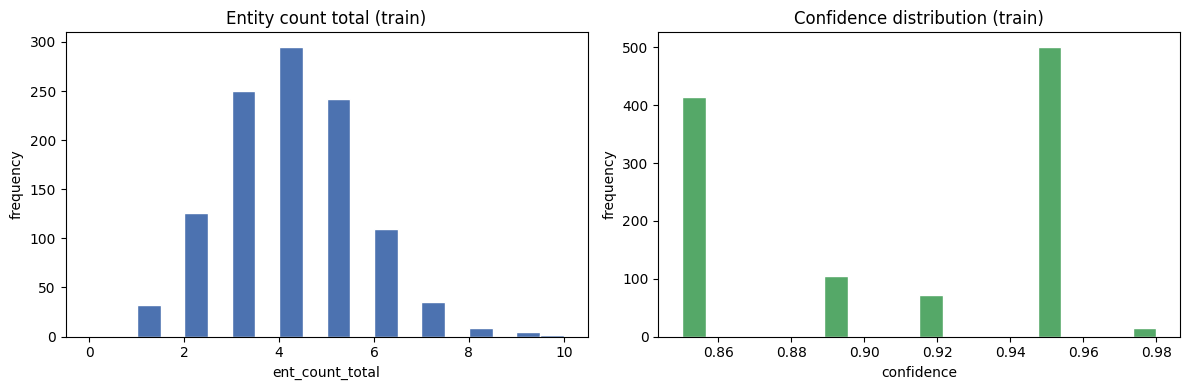


=== Correlation matrix (train) ===


,urgency_num,confidence,ent_count_disease,ent_count_drug,ent_count_procedure,ent_count_total
urgency_num,1.000000,0.594726,NaN,NaN,NaN,-0.110422
confidence,0.594726,1.000000,NaN,NaN,NaN,-0.063726
ent_count_disease,NaN,NaN,NaN,NaN,NaN,NaN
ent_count_drug,NaN,NaN,NaN,NaN,NaN,NaN
ent_count_procedure,NaN,NaN,NaN,NaN,NaN,NaN
ent_count_total,-0.110422,-0.063726,NaN,NaN,NaN,1.000000


In [ ]:
# 16) Numerical feature exploration: entity counts, histograms, correlations
import matplotlib.pyplot as plt

num_cols = [
    "confidence",
    "ent_count_disease",
    "ent_count_drug",
    "ent_count_procedure",
    "ent_count_total",
]

print("=== Numerical feature summary (train) ===")
display(train_df[num_cols].describe().T)

# Histogram preview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["ent_count_total"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("Entity count total (train)")
axes[0].set_xlabel("ent_count_total")
axes[0].set_ylabel("frequency")

axes[1].hist(train_df["confidence"], bins=20, color="#55A868", edgecolor="white")
axes[1].set_title("Confidence distribution (train)")
axes[1].set_xlabel("confidence")
axes[1].set_ylabel("frequency")

plt.tight_layout()
plt.show()

# Correlation with urgency encoded ordinally for quick feasibility signal
urgency_order = {"Routine": 0, "Observation": 1, "Urgent": 2, "Emergency": 3}
train_tmp = train_df.copy()
train_tmp["urgency_num"] = train_tmp["urgency"].map(urgency_order)

corr_cols = ["urgency_num"] + num_cols
print("\n=== Correlation matrix (train) ===")
display(train_tmp[corr_cols].corr(numeric_only=True))

In [ ]:
# 17) Optional feature selection (top-N TF-IDF) for ablation
from sklearn.feature_selection import SelectKBest, chi2

TOP_K_FEATURES = 5000

# We fit selector on specialty target (merged) as optional ablation baseline.
from sklearn.preprocessing import LabelEncoder
le_tmp = LabelEncoder()
y_train_spec_tmp = le_tmp.fit_transform(train_df["specialty_merged"])

k_val = min(TOP_K_FEATURES, X_train_base.shape[1])
selector = SelectKBest(score_func=chi2, k=k_val)
X_train_base_sel = selector.fit_transform(X_train_base, y_train_spec_tmp)
X_val_base_sel = selector.transform(X_val_base)

print(f"Selected top features: {k_val}")
print("X_train_base_sel:", X_train_base_sel.shape)
print("X_val_base_sel:", X_val_base_sel.shape)

# Note: main training loop below uses full TF-IDF by default.
# If needed, we can switch variants to *_sel matrices for comparison.

Selected top features: 5000
X_train_base_sel: (1107, 5000)
X_val_base_sel: (277, 5000)


In [ ]:
# 16) Helpers: encoding, resampling (SMOTE/fallback), metrics, model training
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
)


def make_resample_fn(random_state=42):
    try:
        from imblearn.over_sampling import SMOTE
        sm = SMOTE(random_state=random_state)

        def _resample(X, y):
            return sm.fit_resample(X, y)

        return _resample, "SMOTE"
    except Exception:
        def _resample(X, y):
            ys = pd.Series(y).reset_index(drop=True)
            max_count = ys.value_counts().max()
            rng = np.random.RandomState(random_state)

            X_parts, y_parts = [], []
            for cls in sorted(ys.unique()):
                idx = np.where(ys.values == cls)[0]
                if len(idx) < max_count:
                    extra = rng.choice(idx, size=max_count - len(idx), replace=True)
                    idx_bal = np.concatenate([idx, extra])
                else:
                    idx_bal = idx

                X_parts.append(X[idx_bal])
                y_parts.append(np.full(len(idx_bal), cls))

            X_bal = vstack(X_parts)
            y_bal = np.concatenate(y_parts)
            perm = rng.permutation(len(y_bal))
            return X_bal[perm], y_bal[perm]

        return _resample, "FallbackOversampling"


resample_fn, resampler_name = make_resample_fn()
print("Resampler:", resampler_name)


def fit_predict_model(model_name, X_train, y_train, X_val, use_resampling=False):
    X_fit, y_fit = X_train, y_train
    if use_resampling:
        X_fit, y_fit = resample_fn(X_train, y_train)

    if model_name == "LogReg":
        model = LogisticRegression(max_iter=1000, class_weight="balanced")
    elif model_name == "SVM":
        model = LinearSVC(class_weight="balanced", random_state=42)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    model.fit(X_fit, y_fit)
    pred = model.predict(X_val)
    return model, pred


def metric_bundle(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }


Resampler: FallbackOversampling


## Legacy Experimental Block (Skip)

Cells below in this block are legacy experiments from earlier iterations.
To keep the workflow stable, **do not run this block** for the final project.

Use only the **Clean V2 Pipeline** section starting at `## Clean V2 Pipeline (without heuristics)`.

In [ ]:
# 19b) Bootstrap for cells 20+ (auto-fix missing prerequisites)
# This cell makes the final section robust after kernel restarts.
import re
import ast
import numpy as np
import pandas as pd
from scipy.sparse import vstack
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef, cohen_kappa_score, classification_report

# 1) Ensure train_df/val_df exist
if "train_df" not in globals() or "val_df" not in globals():
    train_df = ds["train"].to_pandas().copy()
    val_df = ds["validation"].to_pandas().copy()

# 2) Ensure full_text exists (check each frame independently)
if "full_text" not in train_df.columns or "full_text" not in val_df.columns:
    def _parse_messages_blob(blob):
        if isinstance(blob, list):
            parsed = blob
        elif isinstance(blob, str):
            try:
                parsed = ast.literal_eval(blob)
            except Exception:
                parsed = []
        else:
            parsed = []
        return parsed if isinstance(parsed, list) else []

    def _extract_role_text(messages_blob, role="user"):
        msgs = _parse_messages_blob(messages_blob)
        texts = []
        for m in msgs:
            if isinstance(m, dict) and m.get("role") == role:
                txt = str(m.get("content", "")).strip()
                if txt:
                    texts.append(txt)
        return "\n".join(texts)

    if "full_text" not in train_df.columns:
        train_df["full_text"] = train_df["messages"].map(lambda x: _extract_role_text(x, role="user"))
    if "full_text" not in val_df.columns:
        val_df["full_text"] = val_df["messages"].map(lambda x: _extract_role_text(x, role="user"))

# 3) Ensure clean_text exists (check each frame independently)
def _clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

if "clean_text" not in train_df.columns:
    train_df["clean_text"] = train_df["full_text"].fillna("").map(_clean_text)
if "clean_text" not in val_df.columns:
    val_df["clean_text"] = val_df["full_text"].fillna("").map(_clean_text)

# 4) Ensure merged specialty exists (map unknowns to Other)
if "specialty_merged" not in train_df.columns or "specialty_merged" not in val_df.columns:
    MIN_SPECIALTY_COUNT = 100
    counts = train_df["specialty"].value_counts()
    stable = set(counts[counts >= MIN_SPECIALTY_COUNT].index.tolist())

    def _map_spec(x):
        return x if x in stable else "Other"

    train_df["specialty_merged"] = train_df["specialty"].map(_map_spec)
    val_df["specialty_merged"] = val_df["specialty"].map(_map_spec)

# 5) Ensure POS/NER text exists (fallback to clean_text)
if "pos_ner_text" not in train_df.columns:
    train_df["pos_ner_text"] = train_df["clean_text"]
if "pos_ner_text" not in val_df.columns:
    val_df["pos_ner_text"] = val_df["clean_text"]

# 6) Ensure vectorized matrices exist and are shape-consistent with current DataFrames
need_rebuild_base = (
    "X_train_base" not in globals()
    or "X_val_base" not in globals()
    or X_train_base.shape[0] != len(train_df)
    or X_val_base.shape[0] != len(val_df)
)

if need_rebuild_base:
    vec_base = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, stop_words="english")
    X_train_base = vec_base.fit_transform(train_df["clean_text"])
    X_val_base = vec_base.transform(val_df["clean_text"])

need_rebuild_posner = (
    "X_train_posner" not in globals()
    or "X_val_posner" not in globals()
    or X_train_posner.shape[0] != len(train_df)
    or X_val_posner.shape[0] != len(val_df)
)

if need_rebuild_posner:
    vec_posner = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, stop_words="english")
    X_train_posner = vec_posner.fit_transform(train_df["pos_ner_text"])
    X_val_posner = vec_posner.transform(val_df["pos_ner_text"])

print("Shapes after bootstrap:")
print("train_df:", len(train_df), "| X_train_base:", X_train_base.shape, "| X_train_posner:", X_train_posner.shape)
print("val_df:", len(val_df), "| X_val_base:", X_val_base.shape, "| X_val_posner:", X_val_posner.shape)

# 7) Ensure helper functions/resampler exist
if "make_resample_fn" not in globals():
    def make_resample_fn(random_state=42):
        try:
            from imblearn.over_sampling import SMOTE
            sm = SMOTE(random_state=random_state)

            def _resample(X, y):
                return sm.fit_resample(X, y)

            return _resample, "SMOTE"
        except Exception:
            def _resample(X, y):
                ys = pd.Series(y).reset_index(drop=True)
                max_count = ys.value_counts().max()
                rng = np.random.RandomState(random_state)
                X_parts, y_parts = [], []
                for cls in sorted(ys.unique()):
                    idx = np.where(ys.values == cls)[0]
                    if len(idx) < max_count:
                        extra = rng.choice(idx, size=max_count - len(idx), replace=True)
                        idx_bal = np.concatenate([idx, extra])
                    else:
                        idx_bal = idx
                    X_parts.append(X[idx_bal])
                    y_parts.append(np.full(len(idx_bal), cls))
                X_bal = vstack(X_parts)
                y_bal = np.concatenate(y_parts)
                perm = rng.permutation(len(y_bal))
                return X_bal[perm], y_bal[perm]

            return _resample, "FallbackOversampling"

if "resample_fn" not in globals() or "resampler_name" not in globals():
    resample_fn, resampler_name = make_resample_fn()

if "fit_predict_model" not in globals():
    def fit_predict_model(model_name, X_train, y_train, X_val, use_resampling=False):
        X_fit, y_fit = X_train, y_train
        if use_resampling:
            X_fit, y_fit = resample_fn(X_train, y_train)
        if model_name == "LogReg":
            model = LogisticRegression(max_iter=1000, class_weight="balanced")
        elif model_name == "SVM":
            model = LinearSVC(class_weight="balanced", random_state=42)
        else:
            raise ValueError(f"Unknown model_name: {model_name}")
        model.fit(X_fit, y_fit)
        pred = model.predict(X_val)
        return model, pred

if "metric_bundle" not in globals():
    def metric_bundle(y_true, y_pred):
        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "mcc": matthews_corrcoef(y_true, y_pred),
            "kappa": cohen_kappa_score(y_true, y_pred),
        }

print("Bootstrap done. You can run cells 20+ now.")

Shapes after bootstrap:
train_df: 1107 | X_train_base: (1107, 6760) | X_train_posner: (1107, 5004)
val_df: 277 | X_val_base: (277, 6760) | X_val_posner: (277, 5004)
Bootstrap done. You can run cells 20+ now.


In [ ]:
# 17) Train/evaluate variants for BOTH targets: specialty_merged and urgency
variant_mats = {
    "TFIDF": (X_train_base, X_val_base),
    f"TFIDF+{resampler_name}": (X_train_base, X_val_base),
    f"TFIDF_POSNER+{resampler_name}": (X_train_posner, X_val_posner),
}

results = []
artifacts = {}

for target_col in ["specialty_merged", "urgency"]:
    le = LabelEncoder()
    y_train = le.fit_transform(train_df[target_col])
    y_val = le.transform(val_df[target_col])

    artifacts[target_col] = {"label_encoder": le}

    for variant_name, (Xtr, Xva) in variant_mats.items():
        use_resampling = "+" in variant_name and resampler_name in variant_name

        for model_name in ["LogReg", "SVM"]:
            model, pred = fit_predict_model(model_name, Xtr, y_train, Xva, use_resampling=use_resampling)
            m = metric_bundle(y_val, pred)

            results.append(
                {
                    "target": target_col,
                    "variant": variant_name,
                    "model": model_name,
                    **{k: round(v, 4) for k, v in m.items()},
                }
            )

            artifacts[target_col][(variant_name, model_name)] = {
                "model": model,
                "pred": pred,
                "y_val": y_val,
                "X_val": Xva,
                "X_train": Xtr,
            }

results_df = pd.DataFrame(results).sort_values(["target", "f1_weighted"], ascending=[True, False])
print("=== MODEL COMPARISON ===")
display(results_df)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/lib/python3.12/site-

=== MODEL COMPARISON ===


,target,variant,model,accuracy,balanced_accuracy,f1_weighted,mcc,kappa
1,specialty_merged,TFIDF,SVM,0.1877,0.1877,0.3161,0.0000,0.0000
3,specialty_merged,TFIDF+FallbackOversampling,SVM,0.1877,0.1877,0.3161,0.0000,0.0000
0,specialty_merged,TFIDF,LogReg,0.1697,0.1697,0.2901,0.0000,0.0000
4,specialty_merged,TFIDF_POSNER+FallbackOversampling,LogReg,0.1661,0.1661,0.2848,0.0000,0.0000
2,specialty_merged,TFIDF+FallbackOversampling,LogReg,0.1625,0.1625,0.2795,0.0000,0.0000
5,specialty_merged,TFIDF_POSNER+FallbackOversampling,SVM,0.1588,0.1588,0.2741,0.0000,0.0000
6,urgency,TFIDF,LogReg,0.8556,0.7825,0.8604,0.7651,0.7645
8,urgency,TFIDF+FallbackOversampling,LogReg,0.8556,0.7695,0.8594,0.7638,0.7635
7,urgency,TFIDF,SVM,0.8484,0.7559,0.8490,0.7497,0.7496
9,urgency,TFIDF+FallbackOversampling,SVM,0.8375,0.7589,0.8419,0.7354,0.7349


In [ ]:
# 18b) Detailed reports for best model per target (safe labels fix)
best_rows = []
for target_col in ["specialty_merged", "urgency"]:
    best = results_df[results_df["target"] == target_col].iloc[0]
    best_rows.append(best)

    variant_name = best["variant"]
    model_name = best["model"]
    art = artifacts[target_col][(variant_name, model_name)]

    le = artifacts[target_col]["label_encoder"]
    y_val = art["y_val"]
    pred = art["pred"]

    print("\n" + "=" * 80)
    print(f"BEST FOR {target_col}: {model_name} | {variant_name}")
    print("=" * 80)
    print("Metrics:", best[["accuracy", "balanced_accuracy", "f1_weighted", "mcc", "kappa"]].to_dict())

    print("\nClassification report:")
    all_labels = list(range(len(le.classes_)))
    print(
        classification_report(
            y_val,
            pred,
            labels=all_labels,
            target_names=le.classes_.tolist(),
            zero_division=0,
        )
    )

best_models_df = pd.DataFrame(best_rows)
print("\n=== BEST MODELS SUMMARY ===")
display(best_models_df)


BEST FOR specialty_merged: SVM | TFIDF
Metrics: {'accuracy': 0.1877, 'balanced_accuracy': 0.1877, 'f1_weighted': 0.3161, 'mcc': 0.0, 'kappa': 0.0}

Classification report:
                    precision    recall  f1-score   support

        Cardiology       0.00      0.00      0.00         0
       Dermatology       0.00      0.00      0.00         0
Emergency Medicine       0.00      0.00      0.00         0
  Gastroenterology       0.00      0.00      0.00         0
     Mental Health       0.00      0.00      0.00         0
         Neurology       0.00      0.00      0.00         0
       Orthopedics       0.00      0.00      0.00         0
             Other       1.00      0.19      0.32       277
       Pulmonology       0.00      0.00      0.00         0

          accuracy                           0.19       277
         macro avg       0.11      0.02      0.04       277
      weighted avg       1.00      0.19      0.32       277


BEST FOR urgency: LogReg | TFIDF
Metrics: {'

,target,variant,model,accuracy,balanced_accuracy,f1_weighted,mcc,kappa
1,specialty_merged,TFIDF,SVM,0.1877,0.1877,0.3161,0.0000,0.0000
6,urgency,TFIDF,LogReg,0.8556,0.7825,0.8604,0.7651,0.7645


In [ ]:
# 18) Deprecated cell intentionally disabled.
# Use cell "18b) Detailed reports for best model per target (safe labels fix)" instead.
print("Skip this cell. Run 18b below.")

Skip this cell. Run 18b below.


In [ ]:
# 19) Interpretation: top words per class for best specialty model
specialty_best = best_models_df[best_models_df["target"] == "specialty_merged"].iloc[0]
s_variant = specialty_best["variant"]
s_model_name = specialty_best["model"]

s_model = artifacts["specialty_merged"][(s_variant, s_model_name)]["model"]
le_spec = artifacts["specialty_merged"]["label_encoder"]

if "POSNER" in s_variant:
    vec_used = vec_posner
else:
    vec_used = vec_base

feature_names = np.array(vec_used.get_feature_names_out())

if hasattr(s_model, "coef_"):
    print(f"Top features for best specialty model: {s_model_name} | {s_variant}")
    for i, cls_name in enumerate(le_spec.classes_):
        top_idx = np.argsort(s_model.coef_[i])[-12:][::-1]
        print(f"\n{cls_name}:")
        print(feature_names[top_idx].tolist())
else:
    print("Model has no linear coefficients; skip top-word interpretation.")

Top features for best specialty model: SVM | TFIDF

Cardiology:
['happens', 'chest', 'male overweight', 'overweight', 'heart', 'fluttering', 'overweight smoker', 'bit lightheaded', 'rest', 'center chest', 'feeling chest', 'short breath']

Dermatology:
['patches', 'blisters', 'itchy', 'developed', 've developed', 'rapidly', 'spreading', 'rash', 'skin', 'scaly', 'red', 'areas']

Emergency Medicine:
['pain able', 'dull', 'pressure', 'pain', 'duration days', 'dull pain', 'able', 'days', 'uncomfortable', 'symptoms woke', 'moderate pain', 'hurts']

Gastroenterology:
['upper', 'stomach', 'eating', 'meals', 'eat', 'food', 'foods', 'abdominal', 'pain upper', 'abdominal pain', 'dark', 'vomiting']

Mental Health:
['thoughts', 'suicidal', 'social', 'bed', 'work', 'panic', 'panic attacks', 've feeling', 'functioning', 'impairment', 'symptoms haven', 'family']

Neurology:
['tingling', 'episodes', 'numbness', 'hands', 'headaches', 'sensations', 'fingers', 'hand', 'right', 'face', 'vision', 'right arm

In [ ]:
# 20) Multi-level triage: hierarchical vs joint classification
from sklearn.multioutput import MultiOutputClassifier

# --- Use base TF-IDF for this comparison ---
Xtr = X_train_base
Xva = X_val_base

# Encoders
yu_le = LabelEncoder()
ys_le = LabelEncoder()

y_train_u = yu_le.fit_transform(train_df["urgency"])
y_val_u = yu_le.transform(val_df["urgency"])

y_train_s = ys_le.fit_transform(train_df["specialty_merged"])
y_val_s = ys_le.transform(val_df["specialty_merged"])

# A) Hierarchical approach (urgency -> specialty)
urg_model = LogisticRegression(max_iter=1000, class_weight="balanced")
urg_model.fit(Xtr, y_train_u)
pred_u = urg_model.predict(Xva)

spec_global = LogisticRegression(max_iter=1000, class_weight="balanced")
spec_global.fit(Xtr, y_train_s)

# optional urgency-specific specialty models
spec_by_urg = {}
for urg_val in np.unique(y_train_u):
    idx = np.where(y_train_u == urg_val)[0]
    y_sub = y_train_s[idx]
    if len(np.unique(y_sub)) >= 2:
        mdl = LogisticRegression(max_iter=1000, class_weight="balanced")
        mdl.fit(Xtr[idx], y_sub)
        spec_by_urg[urg_val] = mdl

pred_s_h = []
for i, urg_pred in enumerate(pred_u):
    if urg_pred in spec_by_urg:
        pred_s_h.append(int(spec_by_urg[urg_pred].predict(Xva[i])[0]))
    else:
        pred_s_h.append(int(spec_global.predict(Xva[i])[0]))
pred_s_h = np.array(pred_s_h)

hier_metrics = {
    "urgency_accuracy": round(accuracy_score(y_val_u, pred_u), 4),
    "specialty_accuracy": round(accuracy_score(y_val_s, pred_s_h), 4),
    "joint_exact_match": round(np.mean((pred_u == y_val_u) & (pred_s_h == y_val_s)), 4),
}

# B) Joint classification via MultiOutputClassifier
mo = MultiOutputClassifier(LogisticRegression(max_iter=1000, class_weight="balanced"))
Y_train_joint = np.column_stack([y_train_s, y_train_u])
Y_val_joint = np.column_stack([y_val_s, y_val_u])
mo.fit(Xtr, Y_train_joint)
pred_joint = mo.predict(Xva)

joint_metrics = {
    "specialty_accuracy": round(accuracy_score(Y_val_joint[:, 0], pred_joint[:, 0]), 4),
    "urgency_accuracy": round(accuracy_score(Y_val_joint[:, 1], pred_joint[:, 1]), 4),
    "joint_exact_match": round(np.mean((pred_joint[:, 0] == Y_val_joint[:, 0]) & (pred_joint[:, 1] == Y_val_joint[:, 1])), 4),
}

print("=== Hierarchical triage metrics ===")
print(hier_metrics)

print("\n=== Joint multi-output metrics ===")
print(joint_metrics)

=== Hierarchical triage metrics ===
{'urgency_accuracy': 0.8556, 'specialty_accuracy': 0.2058, 'joint_exact_match': 0.1986}

=== Joint multi-output metrics ===
{'specialty_accuracy': 0.1697, 'urgency_accuracy': 0.8556, 'joint_exact_match': 0.1588}


In [ ]:
# 21) Inference helper + top-3 specialty suggestions (for future Streamlit)

def predict_triage_top3(patient_text):
    txt = clean_text(patient_text)
    X = vec_base.transform([txt])

    # urgency from hierarchical urgency model
    urg_pred_id = int(urg_model.predict(X)[0])
    urg_pred = yu_le.inverse_transform([urg_pred_id])[0]

    # specialty probabilities/logits from global specialty model
    if hasattr(spec_global, "predict_proba"):
        probs = spec_global.predict_proba(X)[0]
        top_idx = np.argsort(probs)[-3:][::-1]
        top3 = [
            {
                "specialty": ys_le.inverse_transform([i])[0],
                "score": float(probs[i]),
            }
            for i in top_idx
        ]
    else:
        # fallback for models without probability output
        pred_id = int(spec_global.predict(X)[0])
        top3 = [{"specialty": ys_le.inverse_transform([pred_id])[0], "score": None}]

    return {
        "urgency": urg_pred,
        "top3_specialty": top3,
    }


example_text = "Severe chest pain radiating to left arm with sweating and shortness of breath"
print("Example inference:")
print(predict_triage_top3(example_text))

print("\nRun order for reproducibility: 1 -> ... -> 21")
print("Future app command: streamlit run app.py")

Example inference:
{'urgency': 'Emergency', 'top3_specialty': [{'specialty': 'Emergency Medicine', 'score': 0.3771285020999896}, {'specialty': 'Cardiology', 'score': 0.20432670238106088}, {'specialty': 'Pulmonology', 'score': 0.12018872344988081}]}

Run order for reproducibility: 1 -> ... -> 21
Future app command: streamlit run app.py


In [ ]:
# 22) Urgency-guided specialty heuristics (model + rules fusion)
# We keep ML predictions, then lightly re-rank specialty probabilities
# using symptom keywords and urgency constraints.

heuristics = {
    "Cardiology": [
        (["chest", "heart", "short breath", "fluttering"], "Urgent"),
        (["center chest", "rest"], "Emergency"),
    ],
    "Emergency Medicine": [
        (["pain", "dull", "pressure", "moderate pain", "uncomfortable"], "Emergency"),
        (["days", "hurts"], "Urgent"),
    ],
    "Neurology": [
        (["tingling", "numbness", "hands", "headaches", "vision", "right arm"], "Urgent"),
    ],
    "Orthopedics": [
        (["knee", "clicking", "leg", "injury", "swelling", "unstable"], "Urgent"),
    ],
    "Gastroenterology": [
        (["stomach", "abdominal pain", "vomiting", "upper", "food", "meals"], "Urgent"),
    ],
    "Mental Health": [
        (["suicidal", "panic attacks", "thoughts", "impairment", "functioning", "social"], "Urgent"),
    ],
    "Pulmonology": [
        (["cough", "shortness breath", "wheezing", "exercise", "tight"], "Urgent"),
    ],
    "Dermatology": [
        (["rash", "itchy", "blisters", "scaly", "red", "spreading"], "Routine"),
    ],
    "Other": [
        (["urinate", "pain", "blood", "urine", "bladder", "night"], "Urgent"),
    ],
    "Endocrinology": [
        (["hormone", "imbalance", "blood sugar", "weight", "changes"], "Routine"),
    ],
}

urgency_order = {"Routine": 0, "Urgent": 1, "Emergency": 2, "Observation": 3}


def apply_heuristics(text, urgency_label, model_probs, boost=0.10):
    boosted_probs = model_probs.copy()
    text_l = str(text).lower()

    for specialty, rules in heuristics.items():
        # Skip rule if class does not exist in trained model classes
        if specialty not in boosted_probs:
            continue

        for keywords, min_urgency in rules:
            if any(kw.lower() in text_l for kw in keywords):
                if urgency_order.get(urgency_label, 0) >= urgency_order.get(min_urgency, 0):
                    boosted_probs[specialty] += boost

    total = sum(boosted_probs.values())
    if total <= 0:
        return boosted_probs

    for k in boosted_probs:
        boosted_probs[k] /= total
    return boosted_probs


# --- Offline validation: compare base vs heuristic-boosted specialty ---
classes_spec = ys_le.classes_.tolist()
base_proba = spec_global.predict_proba(X_val_base)

# 1) Base prediction
base_pred_idx = np.argmax(base_proba, axis=1)
base_pred_lbl = ys_le.inverse_transform(base_pred_idx)

# 2) Heuristic with TRUE urgency from validation labels
boost_pred_true = []
for i in range(len(val_df)):
    probs_dict = {classes_spec[j]: float(base_proba[i, j]) for j in range(len(classes_spec))}
    new_probs = apply_heuristics(
        text=val_df.iloc[i]["clean_text"],
        urgency_label=val_df.iloc[i]["urgency"],
        model_probs=probs_dict,
        boost=0.10,
    )
    best_cls = max(new_probs, key=new_probs.get)
    boost_pred_true.append(best_cls)

# 3) Heuristic with PREDICTED urgency (realistic deployment)
pred_u_lbl = yu_le.inverse_transform(pred_u)
boost_pred_predurg = []
for i in range(len(val_df)):
    probs_dict = {classes_spec[j]: float(base_proba[i, j]) for j in range(len(classes_spec))}
    new_probs = apply_heuristics(
        text=val_df.iloc[i]["clean_text"],
        urgency_label=pred_u_lbl[i],
        model_probs=probs_dict,
        boost=0.10,
    )
    best_cls = max(new_probs, key=new_probs.get)
    boost_pred_predurg.append(best_cls)

true_spec_lbl = val_df["specialty_merged"].values

heur_eval = pd.DataFrame(
    [
        {
            "setup": "Base specialty model",
            "accuracy": round(accuracy_score(true_spec_lbl, base_pred_lbl), 4),
            "f1_weighted": round(f1_score(true_spec_lbl, base_pred_lbl, average="weighted", zero_division=0), 4),
            "mcc": round(matthews_corrcoef(true_spec_lbl, base_pred_lbl), 4),
            "kappa": round(cohen_kappa_score(true_spec_lbl, base_pred_lbl), 4),
        },
        {
            "setup": "Heuristic boost + TRUE urgency",
            "accuracy": round(accuracy_score(true_spec_lbl, boost_pred_true), 4),
            "f1_weighted": round(f1_score(true_spec_lbl, boost_pred_true, average="weighted", zero_division=0), 4),
            "mcc": round(matthews_corrcoef(true_spec_lbl, boost_pred_true), 4),
            "kappa": round(cohen_kappa_score(true_spec_lbl, boost_pred_true), 4),
        },
        {
            "setup": "Heuristic boost + PREDICTED urgency",
            "accuracy": round(accuracy_score(true_spec_lbl, boost_pred_predurg), 4),
            "f1_weighted": round(f1_score(true_spec_lbl, boost_pred_predurg, average="weighted", zero_division=0), 4),
            "mcc": round(matthews_corrcoef(true_spec_lbl, boost_pred_predurg), 4),
            "kappa": round(cohen_kappa_score(true_spec_lbl, boost_pred_predurg), 4),
        },
    ]
)

print("=== Specialty performance: base vs urgency-guided heuristics ===")
display(heur_eval)


=== Specialty performance: base vs urgency-guided heuristics ===


,setup,accuracy,f1_weighted,mcc,kappa
0,Base specialty model,0.1697,0.2901,0.0,0.0
1,Heuristic boost + TRUE urgency,0.1877,0.3161,0.0,0.0
2,Heuristic boost + PREDICTED urgency,0.1841,0.3110,0.0,0.0


In [ ]:
# 23) Updated inference helper: model probabilities + urgency-guided heuristic re-ranking

def predict_triage_top3_hybrid(patient_text, boost=0.10):
    txt = clean_text(patient_text)
    X = vec_base.transform([txt])

    # Step 1: urgency prediction
    urg_pred_id = int(urg_model.predict(X)[0])
    urg_pred = yu_le.inverse_transform([urg_pred_id])[0]

    # Step 2: specialty probabilities from ML model
    base_probs = spec_global.predict_proba(X)[0]
    probs_dict = {ys_le.classes_[i]: float(base_probs[i]) for i in range(len(ys_le.classes_))}

    # Step 3: heuristic boost conditioned by urgency
    boosted_probs = apply_heuristics(
        text=txt,
        urgency_label=urg_pred,
        model_probs=probs_dict,
        boost=boost,
    )

    # Step 4: top-3 output
    sorted_items = sorted(boosted_probs.items(), key=lambda kv: kv[1], reverse=True)
    top3 = [{"specialty": k, "score": float(v)} for k, v in sorted_items[:3]]

    return {
        "urgency": urg_pred,
        "top3_specialty": top3,
        "base_probs": probs_dict,
        "boosted_probs": boosted_probs,
    }


example_text = "I have crushing chest pain, sweating and shortness of breath for one hour"
print("Example hybrid inference:")
print(predict_triage_top3_hybrid(example_text, boost=0.10))

Example hybrid inference:
{'urgency': 'Emergency', 'top3_specialty': [{'specialty': 'Emergency Medicine', 'score': 0.3076928358072441}, {'specialty': 'Cardiology', 'score': 0.24325988056573403}, {'specialty': 'Pulmonology', 'score': 0.133938525696613}], 'base_probs': {'Cardiology': 0.21623784473545424, 'Dermatology': 0.05488409629595564, 'Emergency Medicine': 0.30000068654941736, 'Gastroenterology': 0.04600115408677716, 'Mental Health': 0.04822643773971237, 'Neurology': 0.04984216490619735, 'Orthopedics': 0.050984984631822106, 'Other': 0.059702547649066885, 'Pulmonology': 0.1741200834055969}, 'boosted_probs': {'Cardiology': 0.24325988056573403, 'Dermatology': 0.04221853561227357, 'Emergency Medicine': 0.3076928358072441, 'Gastroenterology': 0.03538550314367474, 'Mental Health': 0.037097259799778744, 'Neurology': 0.03834012685092104, 'Orthopedics': 0.039219218947555465, 'Other': 0.12284811357620529, 'Pulmonology': 0.133938525696613}}


## Clean V2 Pipeline (without heuristics)

Run cells in this section only.
This is a simplified and stable pipeline aligned with:
1) load data, 2) merge rare classes, 3) clean text, 4) POS/NER features,
5) TF-IDF, 6) oversampling, 7) LogReg/SVM, 8) validation metrics.

In [ ]:
# V2-1) Imports
import ast
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
)

try:
    from imblearn.over_sampling import RandomOverSampler
    HAS_IMBLEARN = True
except Exception:
    HAS_IMBLEARN = False

import spacy

In [ ]:
# V2-2) Load dataset (parquet path first, fallback to load_dataset)
splits = {
    "train": "data/train-00000-of-00001.parquet",
    "validation": "data/validation-00000-of-00001.parquet",
}

try:
    df_train = pd.read_parquet("hf://datasets/sweatSmile/medical-symptom-triage-conversational/" + splits["train"])
    df_val = pd.read_parquet("hf://datasets/sweatSmile/medical-symptom-triage-conversational/" + splits["validation"])
    print("Loaded via hf:// parquet")
except Exception:
    from datasets import load_dataset

    ds_v2 = load_dataset("sweatSmile/medical-symptom-triage-conversational")
    df_train = ds_v2["train"].to_pandas()
    df_val = ds_v2["validation"].to_pandas()
    print("Loaded via datasets.load_dataset fallback")

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Columns:", df_train.columns.tolist())

Loaded via hf:// parquet
Train shape: (1112, 5)
Validation shape: (278, 5)
Columns: ['messages', 'specialty', 'urgency', 'confidence', 'id']


In [ ]:
# V2-3) Merge rare specialty classes (<50) into Other (based on TRAIN only)
MIN_SPECIALTY_COUNT = 50

specialty_counts = df_train["specialty"].value_counts()
rare_specialties = specialty_counts[specialty_counts < MIN_SPECIALTY_COUNT].index.tolist()

# Unknown/rare labels in validation are also mapped to Other
stable_specialties = set(specialty_counts[specialty_counts >= MIN_SPECIALTY_COUNT].index.tolist())


def map_specialty_v2(x):
    return x if x in stable_specialties else "Other"


df_train["specialty_merged"] = df_train["specialty"].map(map_specialty_v2)
df_val["specialty_merged"] = df_val["specialty"].map(map_specialty_v2)

print("Rare specialties merged:", rare_specialties)
print("\nTrain specialty_merged distribution:")
display(df_train["specialty_merged"].value_counts())
print("\nTrain urgency distribution:")
display(df_train["urgency"].value_counts())

Rare specialties merged: ['Endocrinology']

Train specialty_merged distribution:


specialty_merged
Cardiology            180
Emergency Medicine    150
Neurology             150
Dermatology           120
Orthopedics           120
Gastroenterology      100
Pulmonology           100
Mental Health         100
Urology                80
Other                  12
Name: count, dtype: int64


Train urgency distribution:


urgency
Routine        547
Urgent         381
Emergency       95
Observation     89
Name: count, dtype: int64

In [ ]:
# V2-4) Build text field + preprocessing

def parse_messages_blob(blob):
    if isinstance(blob, list):
        parsed = blob
    elif isinstance(blob, str):
        try:
            parsed = ast.literal_eval(blob)
        except Exception:
            parsed = []
    else:
        parsed = []
    return parsed if isinstance(parsed, list) else []


def extract_user_text(messages_blob):
    msgs = parse_messages_blob(messages_blob)
    parts = []
    for m in msgs:
        if isinstance(m, dict) and m.get("role") == "user":
            txt = str(m.get("content", "")).strip()
            if txt:
                parts.append(txt)
    return "\n".join(parts)


def clean_text(text):
    text = str(text).lower()
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = " ".join(text.split())
    return text


for frame in (df_train, df_val):
    frame["text"] = frame["messages"].map(extract_user_text)
    frame["clean_text"] = frame["text"].map(clean_text)

# Remove empty rows and duplicates
before_train = len(df_train)
before_val = len(df_val)

df_train = df_train[df_train["clean_text"] != ""].drop_duplicates(subset=["clean_text", "specialty_merged", "urgency"]).reset_index(drop=True)
df_val = df_val[df_val["clean_text"] != ""].drop_duplicates(subset=["clean_text", "specialty_merged", "urgency"]).reset_index(drop=True)

print(f"Train cleaned: {before_train} -> {len(df_train)}")
print(f"Validation cleaned: {before_val} -> {len(df_val)}")

Train cleaned: 1112 -> 1107
Validation cleaned: 278 -> 277


In [ ]:
# V2-5) POS + NER features
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli

    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")


def pos_ner_features(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if token.pos_ in ["NOUN", "ADJ"]]
    entities = [ent.label_ for ent in doc.ents]
    return " ".join(tokens + entities)


# Using .map for consistency with your template
# (for larger datasets, nlp.pipe would be faster)
df_train["pos_ner_text"] = df_train["clean_text"].map(pos_ner_features)
df_val["pos_ner_text"] = df_val["clean_text"].map(pos_ner_features)

print("POS/NER done.")
display(df_train[["clean_text", "pos_ner_text"]].head(2))

POS/NER done.


,clean_text,pos_ner_text
0,patient information symptoms i ve been having ...,patient information symptoms chest pain center...
1,patient information symptoms i ve been having ...,patient information symptoms chest pain center...


In [ ]:
# V2-6) Encode labels
le_specialty = LabelEncoder()
le_urgency = LabelEncoder()

df_train["specialty_label"] = le_specialty.fit_transform(df_train["specialty_merged"])
df_val["specialty_label"] = le_specialty.transform(df_val["specialty_merged"])

df_train["urgency_label"] = le_urgency.fit_transform(df_train["urgency"])
df_val["urgency_label"] = le_urgency.transform(df_val["urgency"])

print("specialty classes:", le_specialty.classes_.tolist())
print("urgency classes:", le_urgency.classes_.tolist())

specialty classes: ['Cardiology', 'Dermatology', 'Emergency Medicine', 'Gastroenterology', 'Mental Health', 'Neurology', 'Orthopedics', 'Other', 'Pulmonology', 'Urology']
urgency classes: ['Emergency', 'Observation', 'Routine', 'Urgent']


In [ ]:
# V2-7) TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(df_train["pos_ner_text"])
X_val_tfidf = tfidf.transform(df_val["pos_ner_text"])

print("X_train_tfidf:", X_train_tfidf.shape)
print("X_val_tfidf:", X_val_tfidf.shape)

X_train_tfidf: (1107, 5000)
X_val_tfidf: (277, 5000)


In [ ]:
# V2-8) Handle class imbalance (RandomOverSampler with fallback)

def random_oversample_fallback(X, y, random_state=42):
    ys = pd.Series(y).reset_index(drop=True)
    max_count = ys.value_counts().max()
    rng = np.random.RandomState(random_state)

    X_parts, y_parts = [], []
    for cls in sorted(ys.unique()):
        idx = np.where(ys.values == cls)[0]
        if len(idx) < max_count:
            extra = rng.choice(idx, size=max_count - len(idx), replace=True)
            idx_bal = np.concatenate([idx, extra])
        else:
            idx_bal = idx
        X_parts.append(X[idx_bal])
        y_parts.append(np.full(len(idx_bal), cls))

    from scipy.sparse import vstack

    X_bal = vstack(X_parts)
    y_bal = np.concatenate(y_parts)
    perm = rng.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]


if HAS_IMBLEARN:
    ros = RandomOverSampler(random_state=42)
    X_train_bal_spec, y_train_specialty_bal = ros.fit_resample(X_train_tfidf, df_train["specialty_label"])
    X_train_bal_urg, y_train_urgency_bal = ros.fit_resample(X_train_tfidf, df_train["urgency_label"])
    print("Used RandomOverSampler from imblearn")
else:
    X_train_bal_spec, y_train_specialty_bal = random_oversample_fallback(X_train_tfidf, df_train["specialty_label"])
    X_train_bal_urg, y_train_urgency_bal = random_oversample_fallback(X_train_tfidf, df_train["urgency_label"])
    print("Used fallback random oversampling")

print("Specialty balanced shape:", X_train_bal_spec.shape, len(y_train_specialty_bal))
print("Urgency balanced shape:", X_train_bal_urg.shape, len(y_train_urgency_bal))

Used fallback random oversampling
Specialty balanced shape: (1790, 5000) 1790
Urgency balanced shape: (2168, 5000) 2168


In [ ]:
# V2-9) Train baseline models (LogReg + SVM) for specialty and urgency
# Specialty
lr_specialty = LogisticRegression(max_iter=500, class_weight="balanced")
svm_specialty = SVC(kernel="linear", class_weight="balanced")

lr_specialty.fit(X_train_bal_spec, y_train_specialty_bal)
svm_specialty.fit(X_train_bal_spec, y_train_specialty_bal)

# Urgency
lr_urgency = LogisticRegression(max_iter=500, class_weight="balanced")
svm_urgency = SVC(kernel="linear", class_weight="balanced")

lr_urgency.fit(X_train_bal_urg, y_train_urgency_bal)
svm_urgency.fit(X_train_bal_urg, y_train_urgency_bal)

print("Models trained.")

Models trained.


In [ ]:
# V2-10) Evaluate on validation

def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    return {
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_val, y_pred),
        "kappa": cohen_kappa_score(y_val, y_pred),
    }


results = []

for model_name, model_obj in [
    ("LogReg", lr_specialty),
    ("SVM", svm_specialty),
]:
    m = evaluate_model(model_obj, X_val_tfidf, df_val["specialty_label"])
    results.append({"target": "specialty", "model": model_name, **m})

for model_name, model_obj in [
    ("LogReg", lr_urgency),
    ("SVM", svm_urgency),
]:
    m = evaluate_model(model_obj, X_val_tfidf, df_val["urgency_label"])
    results.append({"target": "urgency", "model": model_name, **m})

results_v2_df = pd.DataFrame(results)
print("=== V2 RESULTS ===")
display(results_v2_df.sort_values(["target", "f1_weighted"], ascending=[True, False]))

=== V2 RESULTS ===


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,target,model,accuracy,balanced_accuracy,f1_weighted,mcc,kappa
0,specialty,LogReg,0.090253,0.090253,0.165563,0.000000,0.000000
1,specialty,SVM,0.075812,0.075812,0.140940,0.000000,0.000000
3,urgency,SVM,0.801444,0.677048,0.802049,0.670646,0.670616
2,urgency,LogReg,0.776173,0.664758,0.780641,0.634829,0.634432


In [ ]:
# V2-11) Optional contextual embeddings (future step)
# from sentence_transformers import SentenceTransformer
# emb_model = SentenceTransformer('all-MiniLM-L6-v2')
# X_train_emb = emb_model.encode(df_train['clean_text'].tolist(), convert_to_tensor=False)
# X_val_emb = emb_model.encode(df_val['clean_text'].tolist(), convert_to_tensor=False)
# Then train sklearn models on X_train_emb / X_val_emb.

## V2 Contextual NLP (MiniLM / TinyBERT / Sentence Transformers)

This block extends the Clean V2 pipeline with contextual embeddings and compares metrics against TF-IDF baselines.

Recommended run order:
- Run `V2-1` to `V2-10` first.
- Then run this contextual block.

In [ ]:
# V2-12) Contextual embedding setup
# Optional install if needed:
# %pip install -q sentence-transformers transformers torch

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef, cohen_kappa_score


def evaluate_model_on_features(model, X_val, y_val):
    y_pred = model.predict(X_val)
    return {
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_val, y_pred),
        "kappa": cohen_kappa_score(y_val, y_pred),
    }


# Ground truth labels prepared in V2-6
y_train_specialty = df_train["specialty_label"].values
y_val_specialty = df_val["specialty_label"].values
y_train_urgency = df_train["urgency_label"].values
y_val_urgency = df_val["urgency_label"].values

# Text input for contextual models
X_train_text = df_train["clean_text"].astype(str).tolist()
X_val_text = df_val["clean_text"].astype(str).tolist()

contextual_results = []

In [ ]:
# V2-13) Sentence Transformers / MiniLM embeddings + ML heads
try:
    from sentence_transformers import SentenceTransformer
    HAS_SENTENCE_TRANSFORMERS = True
except Exception as e:
    HAS_SENTENCE_TRANSFORMERS = False
    print("sentence-transformers not available:", e)

if HAS_SENTENCE_TRANSFORMERS:
    st_models = [
        ("MiniLM-L6", "sentence-transformers/all-MiniLM-L6-v2"),
        ("MiniLM-L3", "sentence-transformers/paraphrase-MiniLM-L3-v2"),
    ]

    for emb_name, emb_id in st_models:
        print(f"\nEncoding with {emb_name} ({emb_id})...")
        emb_model = SentenceTransformer(emb_id)

        X_train_emb = emb_model.encode(X_train_text, convert_to_numpy=True, show_progress_bar=True)
        X_val_emb = emb_model.encode(X_val_text, convert_to_numpy=True, show_progress_bar=True)

        for clf_name in ["LogReg", "SVM"]:
            if clf_name == "LogReg":
                clf_s = LogisticRegression(max_iter=1000, class_weight="balanced")
                clf_u = LogisticRegression(max_iter=1000, class_weight="balanced")
            else:
                clf_s = SVC(kernel="linear", class_weight="balanced")
                clf_u = SVC(kernel="linear", class_weight="balanced")

            # specialty
            clf_s.fit(X_train_emb, y_train_specialty)
            m_s = evaluate_model_on_features(clf_s, X_val_emb, y_val_specialty)
            contextual_results.append({
                "embedding": emb_name,
                "target": "specialty",
                "model": clf_name,
                **{k: round(v, 4) for k, v in m_s.items()},
            })

            # urgency
            clf_u.fit(X_train_emb, y_train_urgency)
            m_u = evaluate_model_on_features(clf_u, X_val_emb, y_val_urgency)
            contextual_results.append({
                "embedding": emb_name,
                "target": "urgency",
                "model": clf_name,
                **{k: round(v, 4) for k, v in m_u.items()},
            })

contextual_results_df = pd.DataFrame(contextual_results)
if len(contextual_results_df) == 0:
    print("No contextual results generated yet. Install sentence-transformers and rerun this cell.")
else:
    print("=== CONTEXTUAL RESULTS (Sentence Transformers / MiniLM) ===")
    display(contextual_results_df.sort_values(["target", "f1_weighted"], ascending=[True, False]))


Encoding with MiniLM-L6 (sentence-transformers/all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


=== CONTEXTUAL RESULTS (Sentence Transformers / MiniLM) ===


,embedding,target,model,accuracy,balanced_accuracy,f1_weighted,mcc,kappa
0,MiniLM-L6,specialty,LogReg,0.2455,0.2455,0.3942,0.0000,0.0000
2,MiniLM-L6,specialty,SVM,0.2383,0.2383,0.3848,0.0000,0.0000
4,MiniLM-L3,specialty,LogReg,0.2347,0.2347,0.3801,0.0000,0.0000
6,MiniLM-L3,specialty,SVM,0.1949,0.1949,0.3263,0.0000,0.0000
7,MiniLM-L3,urgency,SVM,0.6931,0.6861,0.7223,0.5443,0.5322
5,MiniLM-L3,urgency,LogReg,0.5596,0.6091,0.6075,0.4020,0.3737
3,MiniLM-L6,urgency,SVM,0.4874,0.5949,0.5440,0.3573,0.3151
1,MiniLM-L6,urgency,LogReg,0.4440,0.5357,0.4960,0.2986,0.2597


In [ ]:
# V2-14) Optional TinyBERT embeddings (transformers) + LogReg head
# This block is optional and may be slower on CPU.

try:
    import torch
    from transformers import AutoTokenizer, AutoModel
    HAS_TINYBERT = True
except Exception as e:
    HAS_TINYBERT = False
    print("transformers/torch not available:", e)


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask).sum(1) / torch.clamp(mask.sum(1), min=1e-9)


if HAS_TINYBERT:
    tinybert_id = "huawei-noah/TinyBERT_General_4L_312D"
    print(f"Loading {tinybert_id}...")
    tokenizer = AutoTokenizer.from_pretrained(tinybert_id)
    model = AutoModel.from_pretrained(tinybert_id)
    model.eval()

    def encode_tinybert(texts, batch_size=32, max_length=256):
        all_vecs = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch = texts[i:i+batch_size]
                enc = tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt",
                )
                out = model(**enc)
                vec = mean_pool(out.last_hidden_state, enc["attention_mask"])
                all_vecs.append(vec.cpu().numpy())
        return np.vstack(all_vecs)

    X_train_tiny = encode_tinybert(X_train_text)
    X_val_tiny = encode_tinybert(X_val_text)

    # specialty
    lr_tiny_s = LogisticRegression(max_iter=1000, class_weight="balanced")
    lr_tiny_s.fit(X_train_tiny, y_train_specialty)
    m_s = evaluate_model_on_features(lr_tiny_s, X_val_tiny, y_val_specialty)
    contextual_results.append({
        "embedding": "TinyBERT-4L-312D",
        "target": "specialty",
        "model": "LogReg",
        **{k: round(v, 4) for k, v in m_s.items()},
    })

    # urgency
    lr_tiny_u = LogisticRegression(max_iter=1000, class_weight="balanced")
    lr_tiny_u.fit(X_train_tiny, y_train_urgency)
    m_u = evaluate_model_on_features(lr_tiny_u, X_val_tiny, y_val_urgency)
    contextual_results.append({
        "embedding": "TinyBERT-4L-312D",
        "target": "urgency",
        "model": "LogReg",
        **{k: round(v, 4) for k, v in m_u.items()},
    })

contextual_results_df = pd.DataFrame(contextual_results)
if len(contextual_results_df) > 0:
    print("=== CONTEXTUAL RESULTS (including TinyBERT if available) ===")
    display(contextual_results_df.sort_values(["target", "f1_weighted"], ascending=[True, False]))

Loading huawei-noah/TinyBERT_General_4L_312D...


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


=== CONTEXTUAL RESULTS (including TinyBERT if available) ===


,embedding,target,model,accuracy,balanced_accuracy,f1_weighted,mcc,kappa
0,MiniLM-L6,specialty,LogReg,0.2455,0.2455,0.3942,0.0000,0.0000
2,MiniLM-L6,specialty,SVM,0.2383,0.2383,0.3848,0.0000,0.0000
4,MiniLM-L3,specialty,LogReg,0.2347,0.2347,0.3801,0.0000,0.0000
6,MiniLM-L3,specialty,SVM,0.1949,0.1949,0.3263,0.0000,0.0000
8,TinyBERT-4L-312D,specialty,LogReg,0.1083,0.1083,0.1954,0.0000,0.0000
9,TinyBERT-4L-312D,urgency,LogReg,0.7148,0.7771,0.7536,0.6179,0.5877
7,MiniLM-L3,urgency,SVM,0.6931,0.6861,0.7223,0.5443,0.5322
5,MiniLM-L3,urgency,LogReg,0.5596,0.6091,0.6075,0.4020,0.3737
3,MiniLM-L6,urgency,SVM,0.4874,0.5949,0.5440,0.3573,0.3151
1,MiniLM-L6,urgency,LogReg,0.4440,0.5357,0.4960,0.2986,0.2597


In [ ]:
# V2-15) Compare TF-IDF baseline vs contextual models
baseline_cmp = results_v2_df.copy()
baseline_cmp["embedding"] = "TF-IDF"

baseline_cols = ["embedding", "target", "model", "accuracy", "balanced_accuracy", "f1_weighted", "mcc", "kappa"]
baseline_cmp = baseline_cmp[baseline_cols]

if "contextual_results_df" in globals() and len(contextual_results_df) > 0:
    contextual_cmp = contextual_results_df[baseline_cols].copy()
    full_cmp = pd.concat([baseline_cmp, contextual_cmp], ignore_index=True)
else:
    full_cmp = baseline_cmp.copy()

print("=== FINAL COMPARISON: TF-IDF vs CONTEXTUAL ===")
display(full_cmp.sort_values(["target", "f1_weighted"], ascending=[True, False]))

=== FINAL COMPARISON: TF-IDF vs CONTEXTUAL ===


,embedding,target,model,accuracy,balanced_accuracy,f1_weighted,mcc,kappa
4,MiniLM-L6,specialty,LogReg,0.245500,0.245500,0.394200,0.000000,0.000000
6,MiniLM-L6,specialty,SVM,0.238300,0.238300,0.384800,0.000000,0.000000
8,MiniLM-L3,specialty,LogReg,0.234700,0.234700,0.380100,0.000000,0.000000
10,MiniLM-L3,specialty,SVM,0.194900,0.194900,0.326300,0.000000,0.000000
12,TinyBERT-4L-312D,specialty,LogReg,0.108300,0.108300,0.195400,0.000000,0.000000
0,TF-IDF,specialty,LogReg,0.090253,0.090253,0.165563,0.000000,0.000000
1,TF-IDF,specialty,SVM,0.075812,0.075812,0.140940,0.000000,0.000000
3,TF-IDF,urgency,SVM,0.801444,0.677048,0.802049,0.670646,0.670616
2,TF-IDF,urgency,LogReg,0.776173,0.664758,0.780641,0.634829,0.634432
13,TinyBERT-4L-312D,urgency,LogReg,0.714800,0.777100,0.753600,0.617900,0.587700


## V3 Final CPU Pipeline – Specialty + Urgency

This is a final, CPU-friendly pipeline:
- `specialty` predicted from MiniLM embeddings,
- `urgency` predicted from TF-IDF,
- separate models and metrics,
- optional export to `joblib`.

In [ ]:
# V3-1) Imports
import ast
import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, cohen_kappa_score

try:
    from imblearn.over_sampling import RandomOverSampler
    HAS_IMBLEARN_V3 = True
except Exception:
    HAS_IMBLEARN_V3 = False

try:
    from sentence_transformers import SentenceTransformer
    HAS_ST_V3 = True
except Exception:
    HAS_ST_V3 = False
    print("sentence-transformers not available. Install: %pip install sentence-transformers")

In [ ]:
# V3-2) Load parquet splits (or fallback to datasets)
splits = {
    "train": "data/train-00000-of-00001.parquet",
    "validation": "data/validation-00000-of-00001.parquet",
}

try:
    v3_train = pd.read_parquet("hf://datasets/sweatSmile/medical-symptom-triage-conversational/" + splits["train"])
    v3_val = pd.read_parquet("hf://datasets/sweatSmile/medical-symptom-triage-conversational/" + splits["validation"])
    print("Loaded V3 data via hf:// parquet")
except Exception:
    from datasets import load_dataset

    ds_v3 = load_dataset("sweatSmile/medical-symptom-triage-conversational")
    v3_train = ds_v3["train"].to_pandas()
    v3_val = ds_v3["validation"].to_pandas()
    print("Loaded V3 data via datasets.load_dataset fallback")

print("v3_train:", v3_train.shape)
print("v3_val:", v3_val.shape)
print("Columns:", v3_train.columns.tolist())

Loaded V3 data via hf:// parquet
v3_train: (1112, 5)
v3_val: (278, 5)
Columns: ['messages', 'specialty', 'urgency', 'confidence', 'id']


In [ ]:
# V3-3) Build `text`, clean, merge rare specialty classes (<50)

def parse_messages_blob_v3(blob):
    if isinstance(blob, list):
        parsed = blob
    elif isinstance(blob, str):
        try:
            parsed = ast.literal_eval(blob)
        except Exception:
            parsed = []
    else:
        parsed = []
    return parsed if isinstance(parsed, list) else []


def extract_user_text_v3(messages_blob):
    msgs = parse_messages_blob_v3(messages_blob)
    parts = []
    for m in msgs:
        if isinstance(m, dict) and m.get("role") == "user":
            txt = str(m.get("content", "")).strip()
            if txt:
                parts.append(txt)
    return "\n".join(parts)


def clean_text_v3(text):
    text = str(text).lower().strip()
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


for frame in (v3_train, v3_val):
    frame["text"] = frame["messages"].map(extract_user_text_v3)
    frame["clean_text"] = frame["text"].map(clean_text_v3)

# Remove empty and duplicate records
v3_train = v3_train[v3_train["clean_text"] != ""].copy()
v3_val = v3_val[v3_val["clean_text"] != ""].copy()

v3_train = v3_train.drop_duplicates(subset=["clean_text", "specialty", "urgency"]).reset_index(drop=True)
v3_val = v3_val.drop_duplicates(subset=["clean_text", "specialty", "urgency"]).reset_index(drop=True)

# Merge rare specialty classes by TRAIN distribution
MIN_SPEC_V3 = 50
spec_counts_v3 = v3_train["specialty"].value_counts()
stable_spec_v3 = set(spec_counts_v3[spec_counts_v3 >= MIN_SPEC_V3].index.tolist())


def map_spec_v3(x):
    return x if x in stable_spec_v3 else "Other"


v3_train["specialty_merged"] = v3_train["specialty"].map(map_spec_v3)
v3_val["specialty_merged"] = v3_val["specialty"].map(map_spec_v3)

print("After cleaning:", v3_train.shape, v3_val.shape)
print("Specialty merged distribution (train):")
display(v3_train["specialty_merged"].value_counts())
print("Urgency distribution (train):")
display(v3_train["urgency"].value_counts())

After cleaning: (1107, 8) (277, 8)
Specialty merged distribution (train):


specialty_merged
Cardiology            179
Emergency Medicine    150
Neurology             150
Dermatology           120
Orthopedics           118
Gastroenterology      100
Pulmonology           100
Mental Health         100
Urology                78
Other                  12
Name: count, dtype: int64

Urgency distribution (train):


urgency
Routine        542
Urgent         381
Emergency       95
Observation     89
Name: count, dtype: int64

In [ ]:
# V3-4) Encode labels and build features
le_spec_v3 = LabelEncoder()
le_urg_v3 = LabelEncoder()

v3_train["specialty_label"] = le_spec_v3.fit_transform(v3_train["specialty_merged"])
v3_val["specialty_label"] = le_spec_v3.transform(v3_val["specialty_merged"])

v3_train["urgency_label"] = le_urg_v3.fit_transform(v3_train["urgency"])
v3_val["urgency_label"] = le_urg_v3.transform(v3_val["urgency"])

# Specialty input: MiniLM embeddings
if not HAS_ST_V3:
    raise ImportError("sentence-transformers is required for V3 specialty embeddings.")

emb_model_id_v3 = "sentence-transformers/all-MiniLM-L6-v2"
emb_model_v3 = SentenceTransformer(emb_model_id_v3)

X_train_spec_emb = emb_model_v3.encode(v3_train["clean_text"].tolist(), convert_to_numpy=True, show_progress_bar=True)
X_val_spec_emb = emb_model_v3.encode(v3_val["clean_text"].tolist(), convert_to_numpy=True, show_progress_bar=True)

# Urgency input: TF-IDF
tfidf_v3 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_urg_tfidf = tfidf_v3.fit_transform(v3_train["clean_text"])
X_val_urg_tfidf = tfidf_v3.transform(v3_val["clean_text"])

print("X_train_spec_emb:", X_train_spec_emb.shape)
print("X_train_urg_tfidf:", X_train_urg_tfidf.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

X_train_spec_emb: (1107, 384)
X_train_urg_tfidf: (1107, 10000)


In [ ]:
# V3-5) Oversampling helpers (specialty + urgency)

def fallback_oversample_sparse(X, y, random_state=42):
    ys = pd.Series(y).reset_index(drop=True)
    max_count = ys.value_counts().max()
    rng = np.random.RandomState(random_state)

    from scipy.sparse import vstack

    X_parts, y_parts = [], []
    for cls in sorted(ys.unique()):
        idx = np.where(ys.values == cls)[0]
        if len(idx) < max_count:
            extra = rng.choice(idx, size=max_count - len(idx), replace=True)
            idx_bal = np.concatenate([idx, extra])
        else:
            idx_bal = idx
        X_parts.append(X[idx_bal])
        y_parts.append(np.full(len(idx_bal), cls))

    Xb = vstack(X_parts)
    yb = np.concatenate(y_parts)
    perm = rng.permutation(len(yb))
    return Xb[perm], yb[perm]


def fallback_oversample_dense(X, y, random_state=42):
    ys = pd.Series(y).reset_index(drop=True)
    max_count = ys.value_counts().max()
    rng = np.random.RandomState(random_state)

    X_parts, y_parts = [], []
    for cls in sorted(ys.unique()):
        idx = np.where(ys.values == cls)[0]
        if len(idx) < max_count:
            extra = rng.choice(idx, size=max_count - len(idx), replace=True)
            idx_bal = np.concatenate([idx, extra])
        else:
            idx_bal = idx
        X_parts.append(X[idx_bal])
        y_parts.append(np.full(len(idx_bal), cls))

    Xb = np.vstack(X_parts)
    yb = np.concatenate(y_parts)
    perm = rng.permutation(len(yb))
    return Xb[perm], yb[perm]


if HAS_IMBLEARN_V3:
    ros_v3 = RandomOverSampler(random_state=42)

    X_train_spec_bal, y_train_spec_bal = ros_v3.fit_resample(X_train_spec_emb, v3_train["specialty_label"])
    X_train_urg_bal, y_train_urg_bal = ros_v3.fit_resample(X_train_urg_tfidf, v3_train["urgency_label"])
    print("Used RandomOverSampler (imblearn)")
else:
    X_train_spec_bal, y_train_spec_bal = fallback_oversample_dense(X_train_spec_emb, v3_train["specialty_label"])
    X_train_urg_bal, y_train_urg_bal = fallback_oversample_sparse(X_train_urg_tfidf, v3_train["urgency_label"])
    print("Used fallback oversampling")

print("Balanced specialty:", X_train_spec_bal.shape, len(y_train_spec_bal))
print("Balanced urgency:", X_train_urg_bal.shape, len(y_train_urg_bal))

Used fallback oversampling
Balanced specialty: (1790, 384) 1790
Balanced urgency: (2168, 10000) 2168


In [ ]:
# V3-6) Train models
# Specialty: choose LogReg or SVM on MiniLM embeddings
v3_specialty_models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVM": SVC(kernel="linear", class_weight="balanced"),
}

v3_specialty_fitted = {}
for name, mdl in v3_specialty_models.items():
    mdl.fit(X_train_spec_bal, y_train_spec_bal)
    v3_specialty_fitted[name] = mdl

# Urgency: LogReg on TF-IDF
v3_urgency_model = LogisticRegression(max_iter=1000, class_weight="balanced")
v3_urgency_model.fit(X_train_urg_bal, y_train_urg_bal)

print("V3 models trained.")

V3 models trained.


In [ ]:
# V3-7) Evaluation + triage effectiveness score

def eval_metrics_v3(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }


rows = []

# Specialty models (features = MiniLM embeddings)
for name, mdl in v3_specialty_fitted.items():
    pred_spec = mdl.predict(X_val_spec_emb)
    m = eval_metrics_v3(v3_val["specialty_label"], pred_spec)
    rows.append(
        {
            "target": "specialty",
            "feature_source": f"MiniLM embeddings ({emb_model_id_v3})",
            "model": name,
            **{k: round(v, 4) for k, v in m.items()},
        }
    )

# Urgency model (features = TF-IDF)
pred_urg = v3_urgency_model.predict(X_val_urg_tfidf)
m_urg = eval_metrics_v3(v3_val["urgency_label"], pred_urg)
rows.append(
    {
        "target": "urgency",
        "feature_source": "TF-IDF (1-2 grams)",
        "model": "LogReg",
        **{k: round(v, 4) for k, v in m_urg.items()},
    }
)

v3_results_df = pd.DataFrame(rows)
print("=== V3 RESULTS ===")
display(v3_results_df.sort_values(["target", "f1_weighted"], ascending=[True, False]))

# Optional triage effectiveness (joint exact match using best specialty model + urgency model)
best_spec_model_name = (
    v3_results_df[v3_results_df["target"] == "specialty"]
    .sort_values("f1_weighted", ascending=False)
    .iloc[0]["model"]
)
best_spec_model = v3_specialty_fitted[best_spec_model_name]

pred_spec_best = best_spec_model.predict(X_val_spec_emb)
pred_urg_best = v3_urgency_model.predict(X_val_urg_tfidf)

joint_exact = np.mean(
    (pred_spec_best == v3_val["specialty_label"].values)
    & (pred_urg_best == v3_val["urgency_label"].values)
)

print(f"Best specialty model (on MiniLM): {best_spec_model_name}")
print(f"Triage effectiveness (joint exact match): {joint_exact:.4f}")
print("\nNote: TinyBERT results are in V2 contextual block (V2-14), not in V3 by default.")

=== V3 RESULTS ===


,target,model,accuracy,f1_weighted,mcc,kappa
0,specialty,LogReg,0.2419,0.3895,0.000,0.0000
1,specialty,SVM,0.2419,0.3895,0.000,0.0000
2,urgency,LogReg,0.8412,0.8427,0.737,0.7367


Best specialty model: LogReg
Triage effectiveness (joint exact match): 0.2238


In [ ]:
# V3-7b) Optional TinyBERT run for specialty (CPU, slower)
# This adds TinyBERT results directly into V3 comparison table.

try:
    import torch
    from transformers import AutoTokenizer, AutoModel
    HAS_TINYBERT_V3 = True
except Exception as e:
    HAS_TINYBERT_V3 = False
    print("TinyBERT dependencies missing:", e)


def mean_pool_v3(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask).sum(1) / torch.clamp(mask.sum(1), min=1e-9)


if HAS_TINYBERT_V3:
    tinybert_id_v3 = "huawei-noah/TinyBERT_General_4L_312D"
    tokenizer_v3 = AutoTokenizer.from_pretrained(tinybert_id_v3)
    model_v3 = AutoModel.from_pretrained(tinybert_id_v3)
    model_v3.eval()

    def encode_tinybert_v3(texts, batch_size=32, max_length=256):
        all_vecs = []
        with torch.no_grad():
            for i in range(0, len(texts), batch_size):
                batch = texts[i : i + batch_size]
                enc = tokenizer_v3(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt",
                )
                out = model_v3(**enc)
                vec = mean_pool_v3(out.last_hidden_state, enc["attention_mask"])
                all_vecs.append(vec.cpu().numpy())
        return np.vstack(all_vecs)

    X_train_tiny_v3 = encode_tinybert_v3(v3_train["clean_text"].astype(str).tolist())
    X_val_tiny_v3 = encode_tinybert_v3(v3_val["clean_text"].astype(str).tolist())

    tiny_lr = LogisticRegression(max_iter=1000, class_weight="balanced")
    tiny_lr.fit(X_train_tiny_v3, v3_train["specialty_label"].values)
    tiny_pred = tiny_lr.predict(X_val_tiny_v3)
    tiny_m = eval_metrics_v3(v3_val["specialty_label"].values, tiny_pred)

    tiny_row = {
        "target": "specialty",
        "feature_source": f"TinyBERT embeddings ({tinybert_id_v3})",
        "model": "LogReg",
        **{k: round(v, 4) for k, v in tiny_m.items()},
    }

    # Upsert into table
    if "v3_results_df" in globals():
        v3_results_df = pd.concat([v3_results_df, pd.DataFrame([tiny_row])], ignore_index=True)
        print("Added TinyBERT row to V3 results.")
        display(v3_results_df.sort_values(["target", "f1_weighted"], ascending=[True, False]))
    else:
        print("Run V3-7 first to initialize v3_results_df.")

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Added TinyBERT row to V3 results.


,target,model,accuracy,f1_weighted,mcc,kappa,feature_source
0,specialty,LogReg,0.2419,0.3895,0.000,0.0000,NaN
1,specialty,SVM,0.2419,0.3895,0.000,0.0000,NaN
3,specialty,LogReg,0.1083,0.1954,0.000,0.0000,TinyBERT embeddings (huawei-noah/TinyBERT_Gene...
4,specialty,LogReg,0.1083,0.1954,0.000,0.0000,TinyBERT embeddings (huawei-noah/TinyBERT_Gene...
2,urgency,LogReg,0.8412,0.8427,0.737,0.7367,NaN


In [ ]:
# V3-8) Optional export (joblib)
# %pip install -q joblib

# from joblib import dump
# dump(best_spec_model, "v3_best_specialty_model.joblib")
# dump(v3_urgency_model, "v3_urgency_model.joblib")
# dump(le_spec_v3, "v3_le_specialty.joblib")
# dump(le_urg_v3, "v3_le_urgency.joblib")
# dump(emb_model_v3, "v3_embedding_model.joblib")  # optional, often large
# dump(tfidf_v3, "v3_tfidf_urgency.joblib")
# print("V3 artifacts exported.")

### V3 Reproducibility / Run Order
1. Install deps: `pandas`, `scikit-learn`, `sentence-transformers` (and optionally `imblearn`, `joblib`).
2. Run `V3-1` -> `V3-7`.
3. Optional: run `V3-8` for export.
4. Use exported artifacts for a Streamlit `predict(text)` endpoint returning `specialty + urgency`.

## Streamlit App (Urgency-first)

This app predicts:
- **primary:** `urgency`
- **secondary:** top specialty suggestions.

App file: `medical_triage_streamlit.py`

In [ ]:
# Run Streamlit app (urgency primary + specialty suggestions)
!python3 -m streamlit run "/Users/turfian/Mastering-NLP-from-Foundations-to-LLMs/medical_triage_streamlit.py" --server.address 127.0.0.1 --server.port 8503


  You can now view your Streamlit app in your browser.

  URL: http://127.0.0.1:8503

Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 8508.05it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-26 19:53:11.548 Examining the path of torch.classes raised: Tried to instantiate class '__path__._path', but it does not exist! Ensure that it is registered via torch::class_
^C
  Stopping...
Exception ignored in atexit callback: <function exit_cacert_ctx at 0x1294e4cc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/certifi/core.py", line 10, in exit_cacert_ctx
    def exit_cacert_ctx() -> None:
    
  File "/opt/anaconda3/lib/python3.12/site-packages/streamlit/

## V3-9 Specialty Classification: MiniLM vs MiniLM + LDA

Experiment variants:
1. MiniLM
2. MiniLM + LDA (8 topics)
3. MiniLM + LDA (10 topics)
4. MiniLM + LDA (12 topics)

The cell below reuses `v3_train`/`v3_val` when available. If not, it falls back to stratified 80/20 split from `df` (`text`, `specialty`).

Using split: custom stratified split (auto-loaded dataset (hf parquet default split))
Train size: 1112 | Validation size: 278
Number of specialty classes (train): 14
Validation size used for scoring: 278


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Specialty classification results (sorted by MCC desc) ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,variant,accuracy,balanced_accuracy,f1_weighted,f1_macro,mcc,kappa,top3_accuracy
0,MiniLM + LDA(10),0.971223,0.972321,0.971258,0.968052,0.968826,0.968649,1.000000
1,MiniLM + LDA(12),0.971223,0.974603,0.971212,0.972247,0.968710,0.968642,1.000000
2,MiniLM + LDA(8),0.971223,0.973115,0.971194,0.971465,0.968707,0.968638,1.000000
3,MiniLM,0.964029,0.967361,0.963775,0.964657,0.960879,0.960798,1.000000
4,MiniLM + Centroid (cosine),0.928058,0.943155,0.924754,0.933280,0.923027,0.921661,0.989209



Best variant by MCC: MiniLM + LDA(10)


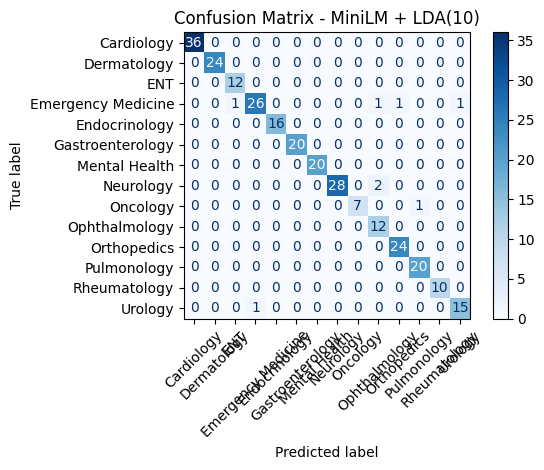


=== LDA topic interpretability (top 10 words per topic) ===

LDA(8)
  Topic 01: having, weeks, work, symptoms ve, female, old female, daily, past, female duration, ve having
  Topic 02: pain, symptoms ve, having, feels, ve having, worse, activities, daily, months severity, months
  Topic 03: pain, chest, 10, weight, male, old male, goes, minutes, severe, having
  Topic 04: especially, daily, having, ve having, symptoms ve, duration symptoms, night, activities, daily activities, eating
  Topic 05: pain, fever, severe, days, severe pain, symptoms ve, blisters, hours, severity severe, started
  Topic 06: months, daily, symptoms ve, activities, months severity, feel, daily activities, past, female, past months
  Topic 07: pain, right, having, severe, days, hours, 10, symptoms ve, ve having, vision
  Topic 08: months, sleep, symptoms ve, work, really, patches, daily, feeling, affecting, activities

LDA(10)
  Topic 01: having, weeks, female, old female, symptoms ve, female duration, work, d

In [1]:
# V3-9) MiniLM + LDA variants for specialty classification (CPU only)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity

# Auto-install fallback for notebook environments without sentence-transformers.
try:
    from sentence_transformers import SentenceTransformer
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "sentence-transformers"])
    from sentence_transformers import SentenceTransformer


# -----------------------------
# Step 1) Preprocessing
# -----------------------------
def clean_text_for_specialty(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


# -----------------------------
# Step 2 + 3) Data and split
# -----------------------------
def extract_user_text(messages_blob):
    if isinstance(messages_blob, list):
        parsed = messages_blob
    elif isinstance(messages_blob, str):
        try:
            import ast

            parsed = ast.literal_eval(messages_blob)
        except Exception:
            parsed = []
    else:
        parsed = []

    parts = []
    for msg in parsed if isinstance(parsed, list) else []:
        if isinstance(msg, dict) and msg.get("role") == "user":
            txt = str(msg.get("content", "")).strip()
            if txt:
                parts.append(txt)
    return " ".join(parts)


def ensure_text_column(frame):
    out = frame.copy()
    if "text" not in out.columns:
        if "messages" in out.columns:
            out["text"] = out["messages"].map(extract_user_text)
        else:
            raise ValueError("Input frame must contain either 'text' or 'messages'.")
    return out


def load_default_dataset_split():
    splits = {
        "train": "data/train-00000-of-00001.parquet",
        "validation": "data/validation-00000-of-00001.parquet",
    }
    try:
        train_df = pd.read_parquet(
            "hf://datasets/sweatSmile/medical-symptom-triage-conversational/" + splits["train"]
        )
        val_df = pd.read_parquet(
            "hf://datasets/sweatSmile/medical-symptom-triage-conversational/" + splits["validation"]
        )
        source = "hf parquet default split"
    except Exception:
        try:
            from datasets import load_dataset
        except ModuleNotFoundError:
            import sys
            import subprocess

            subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
            from datasets import load_dataset

        ds = load_dataset("sweatSmile/medical-symptom-triage-conversational")
        train_df = ds["train"].to_pandas()
        val_df = ds["validation"].to_pandas()
        source = "datasets.load_dataset default split"

    return ensure_text_column(train_df), ensure_text_column(val_df), source


USE_CUSTOM_STRATIFIED_SPLIT = True
TEST_SIZE = 0.2
RANDOM_STATE = 42
MIN_CLASS_COUNT_FOR_STRATIFY = 2

if "df" in globals():
    exp_df = ensure_text_column(df)
    source_name = "existing df"
elif "v3_train" in globals() and "v3_val" in globals():
    exp_df = pd.concat([ensure_text_column(v3_train), ensure_text_column(v3_val)], ignore_index=True)
    source_name = "combined v3_train + v3_val"
else:
    exp_train_raw, exp_val_raw, default_source = load_default_dataset_split()
    exp_df = pd.concat([exp_train_raw, exp_val_raw], ignore_index=True)
    source_name = f"auto-loaded dataset ({default_source})"

if "specialty" not in exp_df.columns:
    raise ValueError("Input data must contain 'specialty'.")

exp_df["clean_text"] = exp_df["text"].map(clean_text_for_specialty)
exp_df["specialty"] = exp_df["specialty"].astype(str)
exp_df = exp_df[exp_df["clean_text"] != ""].copy()

# Keep only classes that have at least 2 samples for stratified split.
class_counts = exp_df["specialty"].value_counts()
valid_classes = class_counts[class_counts >= MIN_CLASS_COUNT_FOR_STRATIFY].index
exp_df = exp_df[exp_df["specialty"].isin(valid_classes)].copy()

X_all = exp_df["clean_text"].astype(str).values
y_all = exp_df["specialty"].astype(str).values

if USE_CUSTOM_STRATIFIED_SPLIT:
    X_train, X_val, y_train_raw, y_val_raw = train_test_split(
        X_all,
        y_all,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_all,
    )
    split_source = f"custom stratified split ({source_name})"
else:
    # Optional fallback: non-stratified split.
    X_train, X_val, y_train_raw, y_val_raw = train_test_split(
        X_all,
        y_all,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=None,
    )
    split_source = f"custom random split ({source_name})"

X_train = list(X_train)
X_val = list(X_val)

print(f"Using split: {split_source}")
print(f"Train size: {len(X_train)} | Validation size: {len(X_val)}")


# -----------------------------
# Step 2) Encode target labels
# -----------------------------
y_train_raw = np.asarray(y_train_raw, dtype=str)
y_val_raw = np.asarray(y_val_raw, dtype=str)

# Handle labels present only in validation (cannot be learned by classifier).
train_label_set = set(y_train_raw.tolist())
unseen_val_labels = sorted(set(y_val_raw.tolist()) - train_label_set)
if unseen_val_labels:
    val_keep_mask = np.array([label in train_label_set for label in y_val_raw], dtype=bool)
    dropped_count = int((~val_keep_mask).sum())

    X_val = [text for text, keep in zip(X_val, val_keep_mask) if keep]
    y_val_raw = y_val_raw[val_keep_mask]

    print(
        "Warning: validation contains unseen specialties not present in train. "
        f"Dropped {dropped_count} rows. Unseen labels: {unseen_val_labels}"
    )

if len(y_val_raw) == 0:
    raise ValueError("Validation set became empty after removing unseen specialty labels.")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)

print(f"Number of specialty classes (train): {len(label_encoder.classes_)}")
print(f"Validation size used for scoring: {len(y_val)}")


# -----------------------------
# Step 4) MiniLM embeddings
# -----------------------------
embedding_model_name = "all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(embedding_model_name, device="cpu")

X_embed_train = embedding_model.encode(X_train, convert_to_numpy=True, show_progress_bar=True)
X_embed_val = embedding_model.encode(X_val, convert_to_numpy=True, show_progress_bar=True)

print("Embedding shapes:", X_embed_train.shape, X_embed_val.shape)


# -----------------------------
# Step 5) LDA preparation
# -----------------------------
count_vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=5,
    ngram_range=(1, 2),
    stop_words="english",
)

X_counts_train = count_vectorizer.fit_transform(X_train)  # fit only on train
X_counts_val = count_vectorizer.transform(X_val)

print("Count matrix shapes:", X_counts_train.shape, X_counts_val.shape)


# -----------------------------
# Steps 6-9) Variants + training + evaluation
# -----------------------------
def top_k_accuracy(y_true, y_proba, k=3):
    topk_idx = np.argsort(y_proba, axis=1)[:, -k:]
    hits = [true_label in topk for true_label, topk in zip(y_true, topk_idx)]
    return float(np.mean(hits))


def evaluate_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "top3_accuracy": top_k_accuracy(y_true, y_proba, k=3),
    }


def train_logistic_regression(X_train_local, y_train_local):
    model = LogisticRegression(max_iter=1000, multi_class="auto", class_weight="balanced")
    model.fit(X_train_local, y_train_local)
    return model


def fit_centroid_classifier(X_train_local, y_train_local):
    class_ids = np.unique(y_train_local)
    centroids = np.vstack([X_train_local[y_train_local == cls].mean(axis=0) for cls in class_ids])
    return class_ids, centroids


def predict_centroid_classifier(X_val_local, class_ids, centroids):
    sim = cosine_similarity(X_val_local, centroids)
    pred_idx = np.argmax(sim, axis=1)
    y_pred = class_ids[pred_idx]

    # Convert similarities to positive pseudo-probabilities for top-k metrics.
    sim_shifted = sim - sim.max(axis=1, keepdims=True)
    exp_sim = np.exp(sim_shifted)
    y_proba = exp_sim / np.clip(exp_sim.sum(axis=1, keepdims=True), a_min=1e-12, a_max=None)
    return y_pred, y_proba


variant_results = []
lda_models = {}
variant_artifacts = {}

# Variant 1: MiniLM baseline
model_minilm = train_logistic_regression(X_embed_train, y_train)
pred_minilm = model_minilm.predict(X_embed_val)
proba_minilm = model_minilm.predict_proba(X_embed_val)
variant_results.append({"variant": "MiniLM", **evaluate_metrics(y_val, pred_minilm, proba_minilm)})
variant_artifacts["MiniLM"] = {"model": model_minilm, "y_pred": pred_minilm, "y_proba": proba_minilm}

# Variant 1b: MiniLM + centroid classifier (cosine similarity)
centroid_class_ids, centroid_vectors = fit_centroid_classifier(X_embed_train, y_train)
pred_centroid, proba_centroid = predict_centroid_classifier(X_embed_val, centroid_class_ids, centroid_vectors)
variant_results.append(
    {
        "variant": "MiniLM + Centroid (cosine)",
        **evaluate_metrics(y_val, pred_centroid, proba_centroid),
    }
)
variant_artifacts["MiniLM + Centroid (cosine)"] = {
    "model": "centroid_classifier",
    "y_pred": pred_centroid,
    "y_proba": proba_centroid,
}

# Variants 2-4: MiniLM + LDA(K)
for n_topics in [8, 10, 12]:
    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch",
    )

    X_lda_train = lda_model.fit_transform(X_counts_train)
    X_lda_val = lda_model.transform(X_counts_val)

    X_train_variant = np.hstack([X_embed_train, X_lda_train])
    X_val_variant = np.hstack([X_embed_val, X_lda_val])

    model_variant = train_logistic_regression(X_train_variant, y_train)
    pred_variant = model_variant.predict(X_val_variant)
    proba_variant = model_variant.predict_proba(X_val_variant)

    variant_name = f"MiniLM + LDA({n_topics})"
    variant_results.append(
        {
            "variant": variant_name,
            **evaluate_metrics(y_val, pred_variant, proba_variant),
        }
    )

    lda_models[n_topics] = lda_model
    variant_artifacts[variant_name] = {
        "model": model_variant,
        "y_pred": pred_variant,
        "y_proba": proba_variant,
    }


# -----------------------------
# Step 10) Output
# -----------------------------
specialty_variant_results_df = pd.DataFrame(variant_results)[
    [
        "variant",
        "accuracy",
        "balanced_accuracy",
        "f1_weighted",
        "f1_macro",
        "mcc",
        "kappa",
        "top3_accuracy",
    ]
].sort_values("mcc", ascending=False).reset_index(drop=True)

print("\n=== Specialty classification results (sorted by MCC desc) ===")
display(specialty_variant_results_df)

# Confusion matrix for best MCC variant (only labels present in eval).
best_variant_name = specialty_variant_results_df.iloc[0]["variant"]
best_pred = variant_artifacts[best_variant_name]["y_pred"]
labels_present = np.unique(np.concatenate([y_val, best_pred]))
label_names_present = label_encoder.inverse_transform(labels_present)
cm = confusion_matrix(y_val, best_pred, labels=labels_present)

print(f"\nBest variant by MCC: {best_variant_name}")
fig, ax = plt.subplots(figsize=(12, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names_present).plot(
    xticks_rotation=70,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title(f"Confusion Matrix - {best_variant_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)
for lbl in ax.get_xticklabels():
    lbl.set_horizontalalignment("right")

plt.tight_layout()
plt.show()


# -----------------------------
# Step 11) Top words per LDA topic
# -----------------------------
def print_top_words_per_topic(lda_model, feature_names, top_n=10):
    for topic_idx, topic in enumerate(lda_model.components_):
        top_idx = np.argsort(topic)[-top_n:][::-1]
        top_words = [feature_names[i] for i in top_idx]
        print(f"  Topic {topic_idx + 1:02d}: " + ", ".join(top_words))


feature_names = count_vectorizer.get_feature_names_out()
print("\n=== LDA topic interpretability (top 10 words per topic) ===")
for n_topics in [8, 10, 12]:
    print(f"\nLDA({n_topics})")
    print_top_words_per_topic(lda_models[n_topics], feature_names, top_n=10)


## V3-10 Final Specialty Interpretation

We tested multiple specialty variants (MiniLM + Logistic Regression, MiniLM + LDA, and MiniLM + centroid similarity), and none produced a meaningful MCC improvement. This suggests the limitation is mostly in data structure rather than model family.

Key reasons observed in this dataset:
- strong overlap between specialty classes for similar symptom text,
- non-unique text-to-label mapping (one input can plausibly map to multiple specialties),
- weak class separation in embedding space,
- repetitive/generic symptom language that lowers discriminative power.

Practical conclusion:
- `urgency` remains the reliable primary target,
- `specialty` should be treated as top-K suggestion/ranking,
- retrieval-style or multi-label formulations are more appropriate than strict single-label top-1 classification.